# Validación — pipeline completo contra la simulación

| Sección | Contenido |
|---|---|
| Fases 0–4 | el algoritmo, sin las celdas de validación |
| Validación | contraste de ambas corridas contra la simulación, fase por fase |

## Cómo se corre

1. `RUN = "volumetrica"` en VAL-0 y correr hasta el final de la Fase 4.
2. `RUN = "difusa"` y lo mismo.
3. Validación: lee las dos corridas desde `resultados/<run>/`.

## Videos (`datos/`)

| Formato | Archivo | Uso |
|---|---|---|
| 5 — nube volumétrica | `nube_volumetrica.avi` | corrida `volumetrica` |
| 6 — nube difusa | `nube_difusa.avi` | corrida `difusa` |
| 3 — terreno + nube roja, sin sombra | `fondo_nube_roja_sin_sombra.avi` | verdad-terreno de la Fase 1 |

---

## VAL-0 — Corrida y entradas de la simulación

La simulación reproduce la escena del 15-ago: la pose de la cámara
(`frame_data`) y la hora (`ts_inicio_video`) se toman de
`datos/config_15ago.json` (copia de `UNIFICADO/resultados/config.json`). Dos ajustes por el formato del render:

- `frame_data` toma el ancho y alto del render (1556×744) y la focal se reescala
  por el ancho, es decir, mismo FOV horizontal que el DJI. **Provisorio** hasta
  tener los parámetros de cámara del render.
- `escala = 1.0`: los umbrales en píxeles de la Fase 1 están fijados para un
  cuadro de trabajo de ~1920 px de ancho; con 0,5 el render quedaría en 778 px.

In [1]:
import os, json, cv2

VIDEOS   = {"volumetrica": "nube_volumetrica.avi",
            "difusa":      "nube_difusa.avi"}
VIDEO_GT = "fondo_nube_roja_sin_sombra.avi"
RUN      = "volumetrica"  

ESCALA_SIM    = 1.0
RUTA_CFG_REAL = os.path.join("datos", "config_15ago.json")

with open(RUTA_CFG_REAL, encoding="utf-8") as fh:
    CFG_REAL = json.load(fh)

_cap = cv2.VideoCapture(os.path.join("datos", VIDEOS[RUN]))
W_SIM = int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_SIM = int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
_cap.release()
if W_SIM == 0:
    raise FileNotFoundError(f"No se pudo abrir datos/{VIDEOS[RUN]}")

_fd = CFG_REAL["frame_data"]
FOCAL_SIM_PX   = float(_fd["focal"]) * W_SIM / float(_fd.get("width") or 3840)
FRAME_DATA_SIM = dict(_fd, width=W_SIM, height=H_SIM, focal=FOCAL_SIM_PX)
TS_INICIO_SIM  = CFG_REAL["ts_inicio_video"]

print(f"corrida {RUN}: {VIDEOS[RUN]}  {W_SIM}x{H_SIM}  |  focal {FOCAL_SIM_PX:.0f} px  |  "
      f"ts {TS_INICIO_SIM}")

corrida volumetrica: nube_volumetrica.avi  1556x744  |  focal 1094 px  |  ts 2025-08-15T16:51:43


---

# FASE 0 — Preprocesamiento, modelo de fondo y georreferenciacion

Resuelve el evento desde el propio video, fija la geometria de la escena en
metros y deja el modelo de fondo. Es la unica fase con `crear=True` y el unico
sitio donde se editan rutas y parametros.


In [2]:
# F0-0 — ARRANQUE 

import sys, os, json, csv, importlib
sys.path.insert(0, os.path.abspath("."))  

import numpy as np, cv2
import matplotlib.pyplot as plt
from IPython.display import display
import funciones as FN
F0, F1, F2, F3, F4 = FN.fases()

CTX = F0.iniciar(
    run             = RUN,
    crear           = True,
    escala          = ESCALA_SIM,
    analisis_fin    = None,
    video_nombre    = VIDEOS[RUN],
    frame_data      = FRAME_DATA_SIM,
    ts_inicio_video = TS_INICIO_SIM,
)

CFG, VID              = CTX["CFG"], CTX["VID"]
FPS, N_FRAMES, FIN    = CTX["FPS"], CTX["N_FRAMES"], CTX["FIN"]
H_WORK, W_WORK, FORMA = CTX["H_WORK"], CTX["W_WORK"], CTX["FORMA"]

  resolviendo el evento desde nube_volumetrica.avi
    ts_inicio_video = 2025-08-15T16:51:43
    camara: lat -22.300393  lon -68.903535  alt 2963.6 m
            yaw -151.7  gimbal -59.7  focal 1094 px
    calibracion: NO la encuentro para 'nube_volumetrica.avi'
      (ninguna)
      la produce la celda C1b de la Fase 0, y la guardara como calibracion_airblast_nube_volumetrica.pkl
    pivot_frame = None   (PENDIENTE: lo pone C0b (onset) o C1b (calibracion))

[config] creada y guardada en resultados\volumetrica\config.json

raiz        : .
run         : volumetrica
resultados  : resultados\volumetrica
video       : datos\nube_volumetrica.avi
escala      : 1.0  |  pivote (sin resolver: lo pone C0b/C1b)  |  GSD None m/px
video   : 1556x744 | 20.00 fps | 521 frames
trabajo : 1556x744 | analisis [?, 521)


[cache] cargado: escaneo_actividad_aa181e04.pkl

[escaneo] 520 frames | grilla 24x16
[escaneo] ratio basal 6.90 -> umbral localizacion 17.24 | 158 frames localizados
[escaneo] actividad basal (fondo NO localizado) 2.90 -> umbral 13.76
[escaneo] 20 episodio(s):
            [f   1, f   1]   1 frames | ratio max 149.18 | fuerza   131.9 (corto pero intenso)
            [f 161, f 165]   5 frames | ratio max 36518.13 | fuerza 36686.4  <- ELEGIDO
            [f 171, f 171]   1 frames | ratio max 15049.92 | fuerza 15032.7 (corto pero intenso)
            [f 178, f 193]  16 frames | ratio max 5885.66 | fuerza 10079.9
            [f 238, f 238]   1 frames | ratio max 89.65 | fuerza    72.4 (corto pero intenso)
            [f 245, f 245]   1 frames | ratio max 38.25 | fuerza    21.0 (corto pero intenso)
            [f 269, f 270]   2 frames | ratio max 3557.74 | fuerza  3561.7 (corto pero intenso)
            [f 276, f 276]   1 frames | ratio max 97.50 | fuerza    80.3 (corto pero intenso)
      

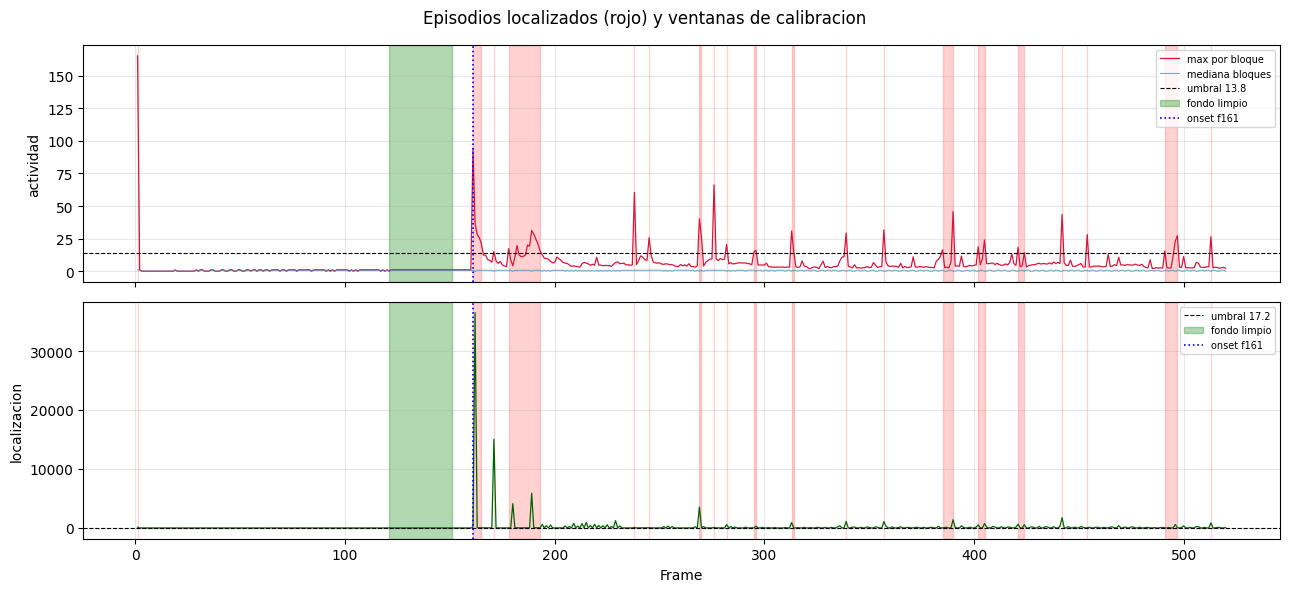

[onset] -> resultados\volumetrica\0_preprocesamiento\onset.json
[config] pivot_frame None -> 161 (escaneo de actividad; C1b lo afina a subframe)
[config] pivote f161 | análisis [161, 521)


In [3]:
# F0-1 — ESCANEO DE ACTIVIDAD  

ONSET_MANUAL    = None   
USAR_ONSET_AUTO = True   

SC  = F0.escaneo_actividad(CFG)
ONS = F0.detectar_onset(SC, FPS, manual=ONSET_MANUAL)
F0.grafico_actividad(SC, ONS, CFG.ruta(0, "escaneo_actividad.png"))

import json as _json
with open(CFG.art_onset, "w", encoding="utf-8") as _fh:
    _json.dump(ONS, _fh, indent=2, ensure_ascii=False)
print(f"[onset] -> {F0.ruta_corta(CFG.art_onset)}")

if CFG.pivot_frame is None:
    print(f"[config] pivot_frame None -> {ONS['frame_guess']} "
          f"(escaneo de actividad; C1b lo afina a subframe)")
    CFG.pivot_frame = ONS["frame_guess"]
    CFG.guardar_json()
elif USAR_ONSET_AUTO and ONS["frame_guess"] != CFG.pivot_frame:
    print(f"[config] pivot_frame {CFG.pivot_frame} -> {ONS['frame_guess']} "
          f"(escaneo de actividad)")
    CFG.pivot_frame = ONS["frame_guess"]
    CFG.guardar_json()
elif not USAR_ONSET_AUTO and ONS["frame_guess"] != CFG.pivot_frame:
    print(f"[config] el escaneo propone f{ONS['frame_guess']} pero se respeta "
          f"el pivot_frame manual f{CFG.pivot_frame} (USAR_ONSET_AUTO=False)")

FIN = CFG.analisis_fin or N_FRAMES
print(f"[config] pivote f{CFG.pivot_frame} | análisis [{CFG.pivot_frame}, {FIN})")


In [4]:
# F0-2 — METADATOS DEL VIDEO

import json
meta = dict(VID, escala=CFG.escala, pivot_frame=CFG.pivot_frame,
            analisis_fin=FIN, ancho_trabajo=W_WORK, alto_trabajo=H_WORK,
            gsd_m_px=CFG.gsd_m_px)
with open(CFG.art_video_meta, "w", encoding="utf-8") as fh:
    json.dump(meta, fh, indent=2)
print(json.dumps(meta, indent=2))

{
  "fps": 20.0,
  "n_frames": 521,
  "ancho": 1556,
  "alto": 744,
  "escala": 1.0,
  "pivot_frame": 161,
  "analisis_fin": 521,
  "ancho_trabajo": 1556,
  "alto_trabajo": 744,
  "gsd_m_px": null
}


[pivote] pivote_manual_sinsello.pkl ya existe: no se vuelve a clicar (FORZAR_PIVOTE=True para rehacerlo).

  resolviendo el evento desde nube_volumetrica.avi
    ts_inicio_video = 2025-08-15T16:51:43
    camara: lat -22.300393  lon -68.903535  alt 2963.6 m
            yaw -151.7  gimbal -59.7  focal 1094 px
    pivot_frame = 161   (fijado a mano)
  config.json actualizado
pivote : (744, 379) px 4K
gsd : 0.21514 m/px
config.json -> pivote_manual_sinsello.pkl


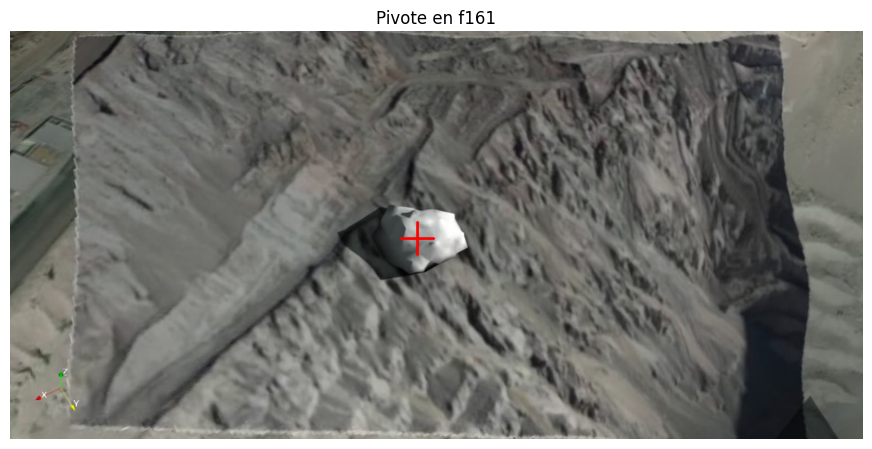

In [5]:
# F0-3 — PIVOTE DE LA TRONADURA

VALIDAR = False
 
if VALIDAR:
    #   PRIMER frame que anotes = el CENTRO (el pivote). Un solo clic.
    #   Los DEMAS               = el FRENTE. Varios clics sobre el arco.
    #   Minimo 3 frames distintos. Cuantos mas puntos, mejor el R2.
    #
    #   a/d ±1 frame   w/s ±10   +/- umbral   m vista   t estela   r rapido
    #   1 vecinos  2 cronicos  3 persistencia  4 arco    [ ] minv   ; ' Karco
    #   f 1:1 (clic derecho centra el 1:1)     z deshacer     Enter o q terminar
    FORZAR_CALIBRACION = False
    PAR_AB = dict(temp_aire_c=15.0)  

    if not str(CFG.calibracion_nombre).startswith("calibracion_airblast"):
        print(f"[calibracion] calibracion_nombre = {CFG.calibracion_nombre} "
              f"-> 'auto' (no es una calibracion acustica)")
        CFG.calibracion_nombre = "auto"

    CAL = F0.calibrar_airblast(CFG, ONS, par=PAR_AB, forzar=FORZAR_CALIBRACION)
    F0.grafico_airblast(CAL, CFG.ruta(0, "ajuste_airblast.png"))

    PIVOTE_NAT = (float(CAL["PIVOT_X_NAT"]), float(CAL["PIVOT_Y_NAT"]))
    GSD_C3     = 1.0 / float(CAL["PPM_NAT"])
    FUENTE_C3  = "airblast (acustica, independiente del DEM)"

else:
    import pickle

    FORZAR_PIVOTE = False  
    LADO_VIS      = 1500    

    _sello  = F0.sello_video(CFG.video_nombre) or "sinsello"
    RUTA_PIV = CFG.ruta(0, f"pivote_manual_{_sello}.pkl")

    def elegir_pivote(ruta_video, frame_ini, n_frames, lado_vis=1500):

        st = {"f": int(frame_ini), "piv": None, "zoom": False, "cen": None}
        vis = {"s": 1.0, "ox": 0, "oy": 0}       

        def _a_nat(xv, yv):
            return (xv / vis["s"] + vis["ox"], yv / vis["s"] + vis["oy"])

        def _cb(ev, x, y, flags, _p):
            if ev == cv2.EVENT_LBUTTONDOWN:
                st["piv"] = _a_nat(x, y)
            elif ev == cv2.EVENT_RBUTTONDOWN:
                st["cen"] = _a_nat(x, y)
                st["zoom"] = True

        VENT = "pivote"
        cv2.namedWindow(VENT, cv2.WINDOW_AUTOSIZE)
        cv2.setMouseCallback(VENT, _cb)

        with F0.LectorVideo(ruta_video, 1.0) as lec:    
            H_NAT, W_NAT = lec.forma_trabajo()              
            alto_vis = int(round(lado_vis * H_NAT / W_NAT))
            cache = {}
            while True:
                fi = int(np.clip(st["f"], 0, n_frames - 1))
                st["f"] = fi
                if fi not in cache:
                    fr = lec[fi]
                    if fr is None:
                        st["f"] = fi - 1
                        continue
                    cache[fi] = fr                        
                    if len(cache) > 24:
                        cache.pop(next(iter(cache)))
                base = cache[fi]

                if st["zoom"]:
                    cx, cy = st["cen"] or (W_NAT / 2, H_NAT / 2)
                    ox = int(np.clip(cx - lado_vis / 2, 0, max(0, W_NAT - lado_vis)))
                    oy = int(np.clip(cy - alto_vis / 2, 0, max(0, H_NAT - alto_vis)))
                    lienzo = base[oy:oy + alto_vis, ox:ox + lado_vis].copy()
                    vis.update(s=1.0, ox=ox, oy=oy)
                    modo = "1:1 (nativo)"
                else:
                    lienzo = cv2.resize(base, (lado_vis, alto_vis))
                    vis.update(s=lado_vis / W_NAT, ox=0, oy=0)
                    modo = f"ajuste x{vis['s']:.2f}"

                if st["piv"] is not None:
                    xv = int(round((st["piv"][0] - vis["ox"]) * vis["s"]))
                    yv = int(round((st["piv"][1] - vis["oy"]) * vis["s"]))
                    if 0 <= xv < lienzo.shape[1] and 0 <= yv < lienzo.shape[0]:
                        cv2.drawMarker(lienzo, (xv, yv), (0, 0, 255),
                                       cv2.MARKER_CROSS, 44, 2)
                        cv2.circle(lienzo, (xv, yv), 14, (0, 255, 255), 1)

                txt = [f"f{fi} / {n_frames - 1}   [{modo}]",
                       "clic = pivote | a/d +-1 | w/s +-10 | f 1:1 | "
                       "clic der. centra | z deshacer | Enter/q ok | ESC cancela"]
                if st["piv"] is not None:
                    txt.append(f"pivote nativo: ({st['piv'][0]:.0f}, {st['piv'][1]:.0f})")
                _pad, _dy = 10, 26
                _alto = min(lienzo.shape[0], _pad * 2 + _dy * len(txt))
                lienzo[0:_alto] = (lienzo[0:_alto] * 0.35).astype(np.uint8)
                for k, s_ in enumerate(txt):
                    cv2.putText(lienzo, s_, (12, _pad + _dy * (k + 1) - 8),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 255, 255), 1,
                                cv2.LINE_AA)

                cv2.imshow(VENT, lienzo)
                t = cv2.waitKey(20) & 0xFF
                if t in (13, ord("q")):
                    break
                elif t == 27:
                    st["piv"] = None
                    break
                elif t == ord("a"):
                    st["f"] -= 1
                elif t == ord("d"):
                    st["f"] += 1
                elif t == ord("w"):
                    st["f"] += 10
                elif t == ord("s"):
                    st["f"] -= 10
                elif t == ord("f"):
                    st["zoom"] = not st["zoom"]
                    st["cen"] = st["cen"] or st["piv"]
                elif t == ord("z"):
                    st["piv"] = None

        cv2.destroyWindow(VENT)
        for _ in range(4):           
            cv2.waitKey(1)
        return st["piv"]


    _prev = None
    if os.path.exists(RUTA_PIV) and not FORZAR_PIVOTE:
        with open(RUTA_PIV, "rb") as fh:
            _prev = pickle.load(fh)
        if _prev.get("VIDEO") != os.path.basename(CFG.video_nombre):
            print(f"[pivote] {os.path.basename(RUTA_PIV)} es de OTRO video: se ignora.")
            _prev = None

    if _prev is not None:
        PIVOTE_NAT = (float(_prev["PIVOT_X_NAT"]), float(_prev["PIVOT_Y_NAT"]))
        GSD_C3     = 1.0 / float(_prev["PPM_NAT"])
        print(f"[pivote] {os.path.basename(RUTA_PIV)} ya existe: no se vuelve a "
              f"clicar (FORZAR_PIVOTE=True para rehacerlo).")
    else:
        print(f"[pivote] clic al CENTRO de la tronadura. Arranco en el frame que "
              f"propuso el escaneo (f{CFG.pivot_frame}); con a/d y w/s puedes "
              f"moverte al que se vea mejor.\n")
        PIVOTE_NAT = elegir_pivote(CFG.video, CFG.pivot_frame, N_FRAMES,
                                   lado_vis=LADO_VIS)
        if PIVOTE_NAT is None:
            raise RuntimeError(
                "No se marco el pivote (se cancelo con ESC).")

        if not os.path.exists(CFG.dem):
            raise FileNotFoundError(
                f"Falta el DEM ({CFG.dem}) y sin el no se puede derivar la "
                f"escala de la metadata. Opciones: deja el DEM en datos/, o "
                f"corre esta celda con VALIDAR=True (el airblast mide la escala "
                f"sin DEM), o fija CFG.gsd_nativo_m_px a mano en F0-0.")

        _dem = F0.cargar_dem(CFG.dem)
        _cam = F0.CamaraGeo.desde_config(CFG, dem=_dem, escala=1.0,
                                         resolver_pivote=False, verbose=False)
        _pts = F0.raycast_pixeles(_cam, _dem, PIVOTE_NAT[0], PIVOTE_NAT[1])
        if not np.isfinite(_pts[0]).all():
            raise RuntimeError(
                "El rayo del pivote no corta el DEM. O el clic cayo en el cielo, "
                "o el DEM no cubre la zona, o la pose de la telemetria esta "
                "mal.")
        _rango = float(np.linalg.norm(_pts[0] - _cam.C))
        GSD_C3 = _rango / float(_cam.K[0, 0])

        print(f"\n[escala] pivote UTM   : E {_pts[0][0]:.2f}  N {_pts[0][1]:.2f}  "
              f"z {_pts[0][2]:.2f}")
        print(f"[escala] rango camara : {_rango:.2f} m   (focal {_cam.K[0,0]:.0f} px)")
        print(f"[escala] gsd nativo   : {GSD_C3:.5f} m/px  "
              f"-> {GSD_C3/CFG.escala:.5f} m/px de trabajo")

        _cal = dict(
            PIVOT_X_NAT=float(PIVOTE_NAT[0]), PIVOT_Y_NAT=float(PIVOTE_NAT[1]),
            PPM_NAT=1.0 / GSD_C3,
            VIDEO=os.path.basename(CFG.video_nombre),
            METODO="pivote manual (1 clic) + escala del modelo de camara",
            RANGO_M=_rango, FOCAL_PX_NAT=float(_cam.K[0, 0]),
            PIVOTE_UTM=[float(v) for v in _pts[0]],
            DEM=os.path.basename(CFG.dem_nombre),
            FRAME_CLIC=int(CFG.pivot_frame),
        )
        with open(RUTA_PIV, "wb") as fh:
            pickle.dump(_cal, fh)
        print(f"\n[pivote] -> {F0.ruta_corta(RUTA_PIV)}   (sellado para {_cal['VIDEO']})")
        del _dem, _cam, _pts

    CFG.calibracion_nombre = os.path.basename(RUTA_PIV)


print()
F0.refrescar_evento(CFG)
print(f"pivote : ({PIVOTE_NAT[0]:.0f}, {PIVOTE_NAT[1]:.0f}) px 4K")
print(f"gsd : {GSD_C3:.5f} m/px")
print(f"config.json -> {CFG.calibracion_nombre}")

with F0.LectorVideo(CFG.video, CFG.escala) as _lec:
    _fr = _lec[int(CFG.pivot_frame)]
_vis = _fr.copy()
_px = (int(PIVOTE_NAT[0] * CFG.escala), int(PIVOTE_NAT[1] * CFG.escala))
cv2.drawMarker(_vis, _px, (0, 0, 255), cv2.MARKER_CROSS, 60, 3)
plt.figure(figsize=(11, 6)); plt.imshow(_vis[:, :, ::-1])
plt.title(f"Pivote en f{CFG.pivot_frame}")
plt.axis("off"); plt.show()

In [6]:
# F0-4 — GEOMETRÍA DE LA ESCENA (pivote en píxeles + escala métrica)

GEO = F0.resolver_geometria(CFG, W_WORK, H_WORK)
F0.guardar_geometria(GEO, CFG.art_geometria)
CFG.gsd_nativo_m_px = GEO["gsd_nativo"]
CFG.guardar_json()

PIVOTE_PX_NAT = tuple(GEO["pivote_px_nat"])      # (x, y) en px NATIVOS (4K)
PIVOTE_PX     = tuple(GEO["pivote_px_trabajo"])  # (x, y) en px de TRABAJO
GSD_NAT       = GEO["gsd_nativo"]                # m/px en 4K
GSD_WORK      = GEO["gsd_trabajo"]               # m/px de trabajo
PPM_NAT       = 1.0 / GSD_NAT                    # px/m en 4K
T0_SUBFRAME   = GEO["t0_subframe"]               # timestamp del subframe
BLAST_FRAME   = GEO["blast_frame"]               # frame de la detonación

[geo] pivote  : nat (744, 379)  ->  trabajo (744, 379)   [PIVOT_X_NAT/PIVOT_Y_NAT (nativos por el sufijo de la clave)]
[geo] gsd     : 0.21514 m/px nativo  ->  0.21514 m/px trabajo   [PPM_NAT = 4.6482 px/m (nativos)]
[geo] cuadro  : 335 x 160 m   <- si esto no es plausible, la escala esta mal
[geo] disparo : t0=161.000 -> frame 161   (CFG.pivot_frame=161)
[geo] tranquila: [f121, f151)   [escaneo de actividad (onset.json)]
[geo] -> resultados\volumetrica\0_preprocesamiento\geometria.json


In [7]:
# F0-5 — MODELO DE FONDO (mediana pre-tronadura + ruido robusto MAD)

PREPROC   = F0.PREPROC_DEFECTO     
BG_WINDOW = F0.BG_WINDOW_DEFECTO   

preproc = F0.preprocesador(PREPROC)
bg_gray, bg_color, noise = F0.modelo_fondo(
    CFG.video, CFG.pivot_frame, escala=CFG.escala, preproc=preproc,
    dir_salida=CFG.dir_fase(0), bg_window=BG_WINDOW, step=1)

_ = F0.guardar_fondo(CFG.art_fondo, bg_gray, bg_color, noise,
                     meta=dict(preproc=PREPROC, bg_window=BG_WINDOW,
                               escala=CFG.escala, pivot=CFG.pivot_frame))

Fondo con frames [121, 161) paso 1 (escala 1.0, blur=(5, 5))...
Ruido robusto (MAD) promedio: 1.40 niveles
[fase0] fondo -> resultados\volumetrica\0_preprocesamiento\modelo_fondo.npz


## F0-7 — GEORREFERENCIA DEL FRAME  (necesita DEM)


In [8]:
dem = F0.cargar_dem(CFG.dem)
cam = F0.CamaraGeo.desde_config(CFG, dem=dem)

print()
ESC = F0.verificar_escala(cam, GSD_NAT)

YAW_OPT = None
if os.path.exists(CFG.satelital):
    _bgg = cv2.cvtColor(cv2.imread(CFG.ruta(0, "bg_color.png")), cv2.COLOR_BGR2GRAY)
    print()
    YAWS, COR, YAW_OPT = F0.barrido_yaw(
        cam, dem, CFG.satelital, _bgg,
        CFG.frame_data["drone_yaw_deg"], CFG.frame_data["gimbal_pitch_deg"],
        delta=20.0, paso=2.5)
else:
    print(f"\n  (falta {F0.ruta_corta(CFG.satelital)}: sin barrido de yaw.")

print()
GEOREF = F0.georreferenciar_frame(CFG, cam, dem)
import json

GEOJSON = dict(
    video       = os.path.basename(CFG.video_nombre),
    dem         = os.path.basename(CFG.dem_nombre),
    crs         = str(dem["crs"]),
    escala      = CFG.escala,
    pivot_frame = int(CFG.pivot_frame),
    camara      = dict(C_utm    = [float(v) for v in cam.C],
                       R_c_w    = [[float(v) for v in fila] for fila in cam.R],
                       focal_px = float(cam.K[0, 0]),
                       ancho_px = int(cam.W), alto_px = int(cam.H)),
    pivote_utm  = [float(v) for v in cam.origen_utm],
    z_piso      = float(cam.z_piso),
    escala_airblast = ESC,
    yaw         = dict(metadatos_deg  = float(CFG.frame_data["drone_yaw_deg"]),
                       optimo_deg     = (float(YAW_OPT) if YAW_OPT is not None
                                         else None),
                       resolucion_deg = 10.0),
    sol         = cam.sol,
)
with open(CFG.art_georreferencia, "w", encoding="utf-8") as fh:
    json.dump(GEOJSON, fh, indent=2, ensure_ascii=False)
print(f"[georef] -> {F0.ruta_corta(CFG.art_georreferencia)}")


  DEM EPSG:32719 | archivo (481, 561) | ventana (481, 561) | 12.5 m | z 2216-3373 m
  camara UTM : E 509936.1  N 7533919.9  z 2963.6
  mirada     : azimut 208.3 deg | depresion 59.7 deg
  u_img      -> azimut 298.3 deg
  v_img      -> azimut 28.3 deg
  escala en el plano del piso (m/px nativo): arriba 0.2691 | centro 0.2158 | abajo 0.1801  -> factor 1.49

  rango camara->pivote (modelo camara + DEM) :   235.4 m
  rango implicado por el airblast (PPM_NAT)  :   235.4 m
  discrepancia : -0.0 m  (-0.0 %)
  a modo de contraste, un desfase real de 102 m en el DEM daria -38 % / +38 %

    yaw  -131.7  r = 0.174
  yaw de metadatos  -151.7 deg
  yaw que maximiza la correlacion  -156.7 deg  (r = 0.324)
  diferencia -5.0 deg  ->  el mismo sesgo se traslada al azimut del viento

punto                    px_4K       UTM E        UTM N        z         lat         lon    dist
pivote                 744,379   509886.92   7533813.02  2759.73  -22.301359  -68.904012     235
esq_sup_izq                0

---

# FASE 1 — Deteccion y segmentacion de la columna de gas


| Salidas | Consumido por |
|---|---|
| `mascaras_gas.pkl` | Fases 2, 3 y 4 |
| `overlay_sam2.mp4` | verificación visual |

**Arquitectura — (`funciones_F1`)**

| Etapa | Método |
|---|---|
| Localización semántica | CLIPSeg contrastivo con **consenso multiescala** centrado en el pivote |
| Evidencia física | **novedad** contra el fondo crudo, con registro ECC y ajuste fotométrico |
| Segmentación | SAM 2 video, **opción B unificada**: reversa (nacimiento) + chunking sembrado por máscara propagada |

In [9]:
# F1-0 — ARRANQUE

CTX = F0.iniciar(run=RUN)

CFG, VID              = CTX["CFG"], CTX["VID"]
FPS, N_FRAMES, FIN    = CTX["FPS"], CTX["N_FRAMES"], CTX["FIN"]
H_WORK, W_WORK, FORMA = CTX["H_WORK"], CTX["W_WORK"], CTX["FORMA"]
PIVOTE                = CFG.pivot_frame

[config] leida de resultados\volumetrica\config.json

raiz        : .
run         : volumetrica
resultados  : resultados\volumetrica
video       : datos\nube_volumetrica.avi
escala      : 1.0  |  pivote f161  |  GSD None m/px
video   : 1556x744 | 20.00 fps | 521 frames
trabajo : 1556x744 | analisis [161, 521)


## F1-1 — GEOMETRÍA Y FONDO CRUDO


In [10]:
PIVOTE_PX_MANUAL = None   
GSD_MANUAL       = None   

GEO, _ = F1.geometria_escena(CFG, W_WORK, H_WORK)
PX, PY = F1.resolver_pivote_px(CFG, W_WORK, H_WORK,
                               manual=PIVOTE_PX_MANUAL, geo=GEO)
GSD    = F1.resolver_gsd(CFG, W_WORK, manual=GSD_MANUAL, geo=GEO)

VENTANA_FONDO = GEO.get("ventana_tranquila") 
FONDO, RUIDO_BASE = F1.fondo_crudo(CFG.video, PIVOTE, escala=CFG.escala,
                                   rango=VENTANA_FONDO)


[geo] fuente: geometria.json
[geo] pivote 744, 379 px de trabajo | gsd 0.21514 m/px | cuadro 335 m de ancho
[pivote] (744, 379) px de trabajo   [PIVOT_X_NAT/PIVOT_Y_NAT (nativos por el sufijo de la clave)]
[gsd] 0.21514 m/px de trabajo  (PPM_NAT = 4.6482 px/m (nativos))
      ancho del cuadro = 335 m  <- si esto no es plausible, revisa la calibracion
[fondo crudo] 744x1556 de [f121, f151) (30 frames, ventana tranquila de la calibracion) | ruido base = 0.50
              -> novedad_min = 5.0 | novedad_ancla = 25.0


## F1-2 — PARÁMETROS Y MOTOR DE DETECCIÓN


In [11]:
PRESET = "hibrido"

PAR_DET, PAR_SAM = F1.preset(PRESET)

PAR_DET.update(
    escalas_m=(None, 50.0, 30.0), consenso_min=2, lado_min_px=400,
    r_pivote_m=60.0, neg_anillo_m=(60.0, 200.0), pos_repartidos=True,
)
PAR_SAM.update(
    t_busqueda_ini=0.07, t_busqueda_fin=1.85, clip_fuerte=4000, skip=2,
)
print(f"[preset] {PRESET}")
print(f"   det: {PAR_DET}")
print(f"   sam: {PAR_SAM}")

detector = F1.DetectorCLIPSeg(CFG.clipseg_id, dir_local=CFG.dir_clipseg)
DET = F1.Detector(detector, FORMA, (PX, PY), GSD, FONDO, RUIDO_BASE,
                    par=PAR_DET)

LEC = F0.LectorVideo(CFG.video, CFG.escala)
DET.chequeo_registro(LEC, [max(0, PIVOTE - 40), max(0, PIVOTE - 5)])

FIRMA = F0.hash_parametros(dict(motor="V8", preset=PRESET, det=DET.p,
                                sam=PAR_SAM, escala=CFG.escala, pivote=PIVOTE,
                                fin=FIN, px=round(PX, 1), py=round(PY, 1),
                                gsd=round(GSD, 6), ruido=round(RUIDO_BASE, 4),
                                modelo=CFG.clipseg_id))
CACHE_MASKS = f"sam2_{PRESET}_{FIRMA}"
DIR_FRAMES  = os.path.join(CFG.dir_cache, "sam2_frames")   
print(f"\nfirma: {FIRMA} -> {F0.ruta_corta(CACHE_MASKS)}")


[preset] hibrido
   det: {'ventana_max_m': 80.0, 'escalas_m': (None, 50.0, 30.0), 'consenso_min': 2, 'lado_min_px': 400, 'r_pivote_m': 60.0, 'neg_anillo_m': (60.0, 200.0), 'pos_repartidos': True}
   sam: {'ancla_modo': 'primero', 'siembra_mask': False, 'resync_frac': 0.0, 't_busqueda_ini': 0.07, 't_busqueda_fin': 1.85, 'clip_fuerte': 4000, 'skip': 2}


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSeg listo | nube: ['white dust cloud', 'dark gray smoke plume'] | fondo: ['bare rocky terrain', 'dirt road', 'mountain slope', 'dark shadow on the ground']
novedad px > 5.0 | ancla (mediana) > 25.0
pivote (744, 379) | r=60 m = 279 px | anillo negativo 279-930 px
consenso multiescala: completo | +-50m (464px) | +-30m (278px) | piso 400 px
[chequeo] registro ECC: activo
[chequeo] f121: shift=(+0.0, +0.0) px -0.00deg | gain=0.987 | 0.0% sobre umbral
[chequeo] f156: shift=(-0.0, -0.0) px +0.00deg | gain=0.987 | 0.0% sobre umbral
   Objetivo: <10% en todos.

firma: b3b7fcd2 -> sam2_hibrido_b3b7fcd2


## F1-3 — SEGMENTACIÓN SAM 2


In [12]:
_cache = F0.cargar_cache(CACHE_MASKS, CFG.dir_cache)
if isinstance(_cache, dict) and "masks" in _cache and "info" in _cache:
    masks, info = _cache["masks"], _cache["info"]
    print(f"{len(masks)} máscaras desde caché (ancla f{info.get('ancla')}).")
elif _cache is not None:                     
    masks, info = _cache, {}
    print(f"{len(masks)} máscaras desde caché.")
else:
    seg = F1.Segmentador(CFG.sam2_ckpt, CFG.sam2_cfg, CFG.dispositivo)
    masks, info = seg.segmentar(
        CFG.video, DET, FORMA, DIR_FRAMES,
        pivot_frame=PIVOTE, analisis_fin=FIN, fps=FPS, escala=CFG.escala,
        par=PAR_SAM)
    F0.guardar_cache(dict(masks=masks, info=info), CACHE_MASKS, CFG.dir_cache)
    print("\n-- Siembra por bloque --")
    for cid, f0_, tipo, motivo in info["log_siembra"]:
        print(f"  bloque {cid:>2} @ f{f0_:>4} : {tipo:<22} | {motivo}")


[cache] cargado: sam2_hibrido_b3b7fcd2.pkl
181 máscaras desde caché (ancla f162).


## F1-4 — SALIDA + VIDEO DE VERIFICACIÓN


In [13]:
SKIP = PAR_SAM.get("skip", F1.PAR_SAM2["skip"])

F0.guardar_mascaras(masks, CFG.art_mascaras_gas, meta=dict(
    metodo="SAM2",
    firma=FIRMA, skip=SKIP, escala=CFG.escala, forma=FORMA, pivot=PIVOTE,
    gsd_trabajo=GSD, pivote_px=(PX, PY), ruido_base=RUIDO_BASE, **info))

_ = F1.video_overlay(CFG.video, masks, CFG.ruta(1, "overlay_sam2.mp4"),
                 fps=FPS / max(1, SKIP), escala=CFG.escala)

[mascaras] 181 frames -> resultados\volumetrica\1_deteccion_gas\mascaras_gas.pkl (209.5 MB)
[video] resultados\volumetrica\1_deteccion_gas\overlay_sam2.mp4


## F1-5 — Máscaras de sombra (detector multicanal)

El detector viene de **Arjomandi et al. (2022)**: en vez de decidir «sombra vs
gas» con un umbral en grises, suma evidencia de cuatro canales.

| Señal | Cómo separa |
|---|---|
| **L\*** (LAB) | la sombra es oscura → L\* bajo |
| **S** (HSV) | el gas es grisáceo y pierde saturación; la sombra conserva el color del suelo |
| **Cr** (YCrCb) | el gas de tronadura tira a cálido → Cr alto |
| **\|∇\|** | la sombra **conserva** la textura del suelo, el gas la destruye |


In [14]:
PRE_SOMBRA = 40      
SKIP_SOMBRA = 1      

FONDO_COLOR = F1.fondo_crudo_color(CFG.video, PIVOTE, escala=CFG.escala,
                                   rango=GEO.get("ventana_tranquila"))

masks_som, meta_som = F1.detectar_sombras(
    CFG.video, FONDO_COLOR, pivot_frame=PIVOTE, fin=(FIN or N_FRAMES), escala=CFG.escala,
    pre=PRE_SOMBRA, skip=SKIP_SOMBRA,
    umbral=F1.UMBRAL_SOMBRA_V6, area_min=F1.AREA_MIN_SOMBRA_V6)

F0.guardar_mascaras(masks_som, CFG.art_mascaras_sombra, meta=meta_som,
                    empaquetar_bits=True)

F0.sellar(CFG, 1, dict(mascaras=int(len(masks)), skip=int(SKIP),
                       firma=str(FIRMA), pivot_frame=int(CFG.pivot_frame),
                       sombras=int(len(masks_som)),
                       sombras_pre=int(meta_som["n_pre"])))

[fondo crudo color] 744x1556 de [f121, f151) (ventana tranquila de la calibracion)
[sombra multicanal] f121 .. f521  (pre=40, skip=1, umbral=0.55, area_min=800)
  400 mascaras | cobertura media 24.00% (min 17.53%, max 27.94%)
  frames pre-tronadura: 40  (ok, la sombra estatica se puede construir)
[mascaras] 400 frames -> resultados\volumetrica\1_deteccion_gas\mascaras_sombra.pkl (57.9 MB, empaquetadas a bits)


{'video': 'nube_volumetrica.avi',
 'fases': {'0': {'video': 'nube_volumetrica.avi',
   'procedencia': {'video': 'nube_volumetrica.avi',
    'video_bytes': 41330574,
    'ts_inicio_video': 'fijado a mano',
    'frame_data': 'fijado a mano',
    'calibracion': 'fijada a mano: pivote_manual_sinsello.pkl',
    'calibracion_esquema': 'v7.2',
    'pivot_frame': 'PENDIENTE: lo pone C0b (onset) o C1b (calibracion)',
    'insumos_externos': {'dem': 'DEM_mina.tif',
     'ortofoto': 'satelital_utm.tif',
     'bounds_mina': [506500.0, 7532500.0, 513500.0, 7538500.0]}}},
  '1': {'video': 'nube_volumetrica.avi',
   'mascaras': 181,
   'skip': 2,
   'firma': 'b3b7fcd2',
   'pivot_frame': 161,
   'sombras': 400,
   'sombras_pre': 40},
  '2': {'video': 'nube_volumetrica.avi',
   'frames': 46,
   'paso_export': 4,
   'res_vox': 2.5,
   'pivot_frame': 161,
   'h_max_m': 50.23552991978054,
   'sombra': 'multicanal V6 (Arjomandi 2022)'},
  '3': {'video': 'nube_volumetrica.avi',
   'calidad': 'revisar',
   

---

# FASE 2 — Reconstruccion 3D de la columna 


Reconstrucción por intersección de dos vistas: la **cámara del dron** y el
**sol**.

## F2-0 — ARRANQUE


In [15]:
CTX = F0.iniciar(run=RUN)

CFG, VID              = CTX["CFG"], CTX["VID"]
FPS, N_FRAMES, FIN    = CTX["FPS"], CTX["N_FRAMES"], CTX["FIN"]
H_WORK, W_WORK, FORMA = CTX["H_WORK"], CTX["W_WORK"], CTX["FORMA"]
PF = CFG.pivot_frame

F0.exigir_sello(CFG, 1, "mascaras_gas.pkl")

[config] leida de resultados\volumetrica\config.json

raiz        : .
run         : volumetrica
resultados  : resultados\volumetrica
video       : datos\nube_volumetrica.avi
escala      : 1.0  |  pivote f161  |  GSD None m/px
video   : 1556x744 | 20.00 fps | 521 frames
trabajo : 1556x744 | analisis [161, 521)


{'video': 'nube_volumetrica.avi',
 'mascaras': 181,
 'skip': 2,
 'firma': 'b3b7fcd2',
 'pivot_frame': 161,
 'sombras': 400,
 'sombras_pre': 40}

## F2-1 — ESCENA: DEM · CÁMARA · SOL · PIVOTE


In [16]:
ESC = F2.preparar_escena(CFG)
PIVOTE, ORIGEN = ESC["pivote"], ESC["origen"]

RES_VOX     = 2.5      
RADIO_XY    = 150.0    
Z_REL_MIN   = -10.0
Z_REL_MAX   = 120.0
PASO_FRAMES = 20      

DEM:
  archivo   : (481, 561) celdas, res (12.499999999999998, 12.5) m, EPSG:32719
  ventana   : (480, 560) celdas (2.15 MB)
  elevacion : 2216 / 3373 m  (nan: 0.0%)

Camara:
  resolucion : 1556x744  f=1094.1 px
  FOV        : 70.8 x 37.6 deg
  dron UTM   : E 509936.2  N 7533919.9  z 2963.6 m
  mirada     : azimut 208.3 deg | depresion 59.7 deg
  instante   : 2025-08-15 16:51:51  (UTC-4)
  sol        : azimut 294.13 deg | elevacion 18.60 deg
  vec_sol    : E -0.8650  N +0.3874  U +0.3189
  sombra hacia azimut 114.1 deg | largo = 2.97 x altura

geometria: geometria.json
pivote  : f161 | UTM E 509887.03 N 7533812.97 z 2759.74
sol     : az 294.13  elev 18.60
separacion entre vistas: 266 deg  (90 seria el optimo)


## F2-2 — MAPAS DE TERRENO + CORREDOR DE SOMBRA 


In [17]:
TER  = F2.mapas_terreno(ESC, CFG.dir_cache, CFG.usar_cache)
CORR = F2.corredor_sombra(ESC, TER, CFG.dir_cache, CFG.usar_cache,
                          h_max=160.0, paso=6.0, step=4)
print(f"\ntecho de altura medible por sombra ≈ "
      f"{F2.altura_limite_cuadro(ESC, TER):.0f} m")

cargado de cache: terreno_1556x744_p2_s1.npz
  sin terreno 0.00%  |  auto-sombra 3.53%  |  4.73 px/m
cargado de cache: corredor_h160_p6_s4.npz
  memoria 24 MB | alcance 160 m = 476 m de sombra

techo de altura medible por sombra ≈ 53 m


## F2-3 — MÁSCARAS Y EVIDENCIA TERNARIA


In [18]:
UMBRAL_ESTATICA = 0.5
RADIO_ESTATICA  = 5
RADIO_GAS_DESC  = 3

MASK_GAS, _META_GAS = F0.cargar_mascaras(CFG.art_mascaras_gas)

if os.path.exists(CFG.art_mascaras_sombra):
    _sm, _META_SOM = F0.cargar_mascaras(CFG.art_mascaras_sombra)
    MASK_SOM = {int(f): (np.asarray(m) > 0) for f, m in _sm.items()}
    print(f"  sombra: {len(MASK_SOM)} frames  [f{min(MASK_SOM)} .. f{max(MASK_SOM)}]"
          f"  ({_META_SOM.get('metodo','?')})")
    del _sm
else:
    raise FileNotFoundError(
        f"Falta {CFG.art_mascaras_sombra}. Correr la Fase 1 para generar las máscaras de sombra.")

FRAMES_PRE  = sorted(f for f in MASK_SOM if f < PF)
FRAMES_GAS  = sorted(f for f in MASK_GAS if f >= PF)

KEYFRAMES   = FRAMES_GAS[::PASO_FRAMES]
if len(FRAMES_PRE) < 10:
    raise RuntimeError(
        f"Solo {len(FRAMES_PRE)} frames pre-tronadura en las máscaras de sombra. "
        f"Vuelve a correr la Fase 1 con un numero mayor.")

SOMBRA_EST, _ = F2.sombra_estatica(MASK_SOM, FRAMES_PRE, umbral=UMBRAL_ESTATICA)
SOMBRA_COL, EVID = F2.evidencia(KEYFRAMES, MASK_GAS, MASK_SOM, SOMBRA_EST,
                                CORR, ESC, TER, RADIO_ESTATICA, RADIO_GAS_DESC)

  sombra: 400 frames  [f121 .. f520]  (multicanal V6 (Arjomandi 2022))
  frames pre-tronadura : 40 [f121 .. f160]
  sombra estatica      : 18.22% del frame (umbral fraccion >= 0.5)
   frame   gas%  som_col%   ev:-1%
     161   1.33      0.27    28.68
     200   4.35      2.83    30.74
     240   7.41      3.31    33.49
     280   8.70      4.91    34.83
     320  11.01      6.14    36.96
     360  12.72      5.10    38.74
     400  14.83      3.32    41.01
     440  16.03      1.76    42.39
     480  17.30      1.44    43.52
     520  18.84      1.23    44.44


## F2-4 — GRILLA Y PRECÁLCULO DE PROYECCIONES


In [19]:
G = F2.crear_grilla_voxeles(PIVOTE, RADIO_XY, Z_REL_MIN, Z_REL_MAX,
                             RES_VOX, ESC["dem"]["Z_interp"])

_cp = os.path.join(CFG.dir_cache,
                   f"proy_r{RES_VOX}_R{RADIO_XY:.0f}_z{Z_REL_MIN:.0f}_{Z_REL_MAX:.0f}.npz")
PR = None
if CFG.usar_cache and os.path.exists(_cp):
    with np.load(_cp) as _z:
        if len(_z["uc"]) == len(G["P"]):
            PR = {k: _z[k] for k in _z.files}
    if PR is None:
        print(f"caché de otra grilla: se recalcula {os.path.basename(_cp)}")
    else:
        PR["prof_terreno"] = TER["prof_terreno"]
        print(f"cargado de caché: {os.path.basename(_cp)}")
if PR is None:
    PR = F2.precalcular(G, ESC["K"], ESC["H_c_w"], ESC["vec_sol"],
                          ESC["dem"]["Z_interp"], TER["XM"], TER["YM"], TER["ZM"],
                          ESC["W"], ESC["H"], t_max=900.0)
    np.savez_compressed(_cp, uc=PR["uc"], vc=PR["vc"], ok_c=PR["ok_c"],
                        us=PR["us"], vs=PR["vs"], ok_s=PR["ok_s"],
                        P_suelo=PR["P_suelo"])
    print(f"guardado: {F0.ruta_corta(_cp)}")

if G["P"][:, 2].max() > ESC["H_c_w"][2, 3]:
    print("Hay vóxeles por encima de la cámara. Bajar Z_REL_MAX.")

_ = F2.revisar_grilla(G, ESC, MASK_GAS, KEYFRAMES)

  centro   : E 509887.0  N 7533813.0  z terreno 2759.7 m
  grilla   : 121 x 121 x 53 = 775,973 celdas, res 2.5 m
  sobre terreno: 696,269 voxeles (89.7%)
  extension: +-150.0 m en XY | z rel [-10.0, 120.0] m
cargado de caché: proy_r2.5_R150_z-10_120.npz
  grilla suficiente: como maximo 0.5 % de la mascara queda fuera (f280).


## F2-5 — CARVING SOBRE LOS KEYFRAMES


In [20]:
HULL_ENV, HULL_REV, TOPE = {}, {}, {}
print(f"  {'frame':>6} {'ENV':>9} {'REV':>9} {'h_tope':>8} {'sin_info':>9}")
for f in KEYFRAMES:
    r = F2.reconstruir(G, PR, ESC, MASK_GAS[f], EVID[f], SOMBRA_COL[f],
                       res_vox=RES_VOX)
    HULL_ENV[f], HULL_REV[f], TOPE[f] = r["env"], r["rev"], r["tope"]
    h = r["tope"]["h"] if r["tope"] else np.nan
    flag = "" if not r["tope"] else ("?" if r["tope"]["sin_ev"] else
                                     ("*" if r["tope"]["limitado"] else " "))
    print(f"  {f:>6} {r['env'].sum():>9,} {r['rev'].sum():>9,} "
          f"{h:>7.1f}{flag} {r['diag']['frac_sin_info']*100:>8.1f}%")

print("\n  * tope limitado por el borde del cuadro --> cota inferior")
print("  ? sin evidencia de sombra --> cota superior floja")
print("  sin_info = vóxeles vistos como gas cuya sombra no es observable")

   frame       ENV       REV   h_tope  sin_info
     161     3,227     1,014   120.0?     31.2%
     200    10,797     2,290    27.5      32.5%
     240    18,152     4,710    32.5      35.6%
     280    21,136     6,883    37.5      36.9%
     320    26,570    11,173    47.5      39.7%
     360    30,323    12,753    50.0      42.9%
     400    34,694    12,509    52.5*     47.2%
     440    37,058    11,492    50.0      51.0%
     480    39,870    13,403    50.0      53.8%
     520    43,100    13,183    47.5      56.9%

  * tope limitado por el borde del cuadro --> cota inferior
  ? sin evidencia de sombra --> cota superior floja
  sin_info = vóxeles vistos como gas cuya sombra no es observable


## F2-6 — ALTURA POR SOMBRA SOBRE TODOS LOS FRAMES CON GAS


  techo medible por sombra ≈ 53 m 
evidencia para 171 frames nuevos...
  175/181  medidas 81
  181 frames con gas → 81 medidas usables | 100 tocando el borde (descartadas) | 0 sin sombra utilizable | 0 fuera de [3, 120] m
¡Alerta!: La mayoría de las sombras se sale del cuadro
  ley de potencia: h = 15.18·(t+1)^0.58
  altura: 8.7 – 50.2 m


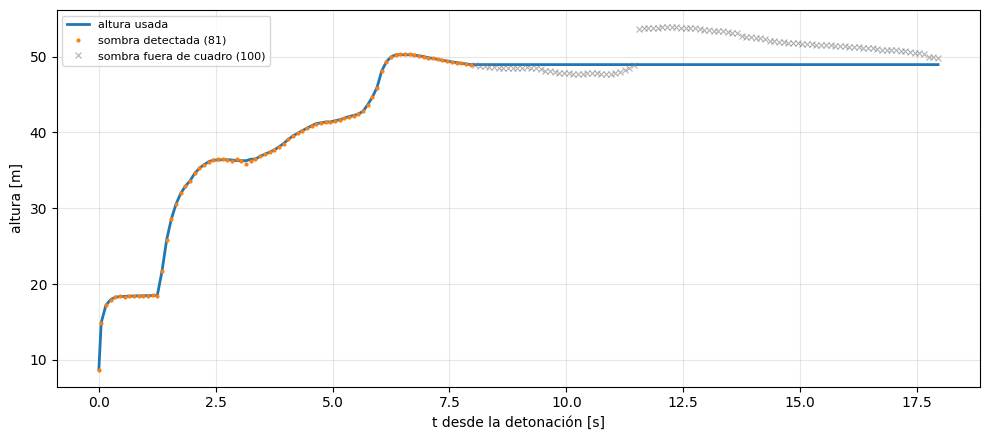

In [21]:
TALLADO_SOLAR = False
H_MIN_FIS, H_MAX_FIS = 3.0, 120.0

HLIM = F2.altura_limite_cuadro(ESC, TER)
print(f"  techo medible por sombra ≈ {HLIM:.0f} m ")

FRAMES_SIM = FRAMES_GAS[:]
falta = [f for f in FRAMES_SIM if f not in SOMBRA_COL]
if falta:
    print(f"evidencia para {len(falta)} frames nuevos...")
    _sc, _ev = F2.evidencia(falta, MASK_GAS, MASK_SOM, SOMBRA_EST, CORR, ESC,
                            TER, RADIO_ESTATICA, RADIO_GAS_DESC, verbose=False)
    SOMBRA_COL.update(_sc); EVID.update(_ev)

H_PUNTA = np.full(len(FRAMES_SIM), np.nan) 
H_CORTE = np.full(len(FRAMES_SIM), np.nan) 
n_sin, n_rango = 0, 0
for i, f in enumerate(FRAMES_SIM):
    occ, _ = F2.carving(G, PR, MASK_GAS[f], EVID[f], usar_sombra=TALLADO_SOLAR)
    occ, _ = F2.regularizar(G, occ, cerrar=1, abrir=1, solo_mayor=True)
    eje = None
    if occ.sum() >= 8:
        _, _R0, eje = F2.revolucion(G, occ, ESC["n_cam"], ESC["n_sol"], k_top=None)
    if SOMBRA_COL[f].sum() < 200:
        n_sin += 1
        continue
    ap = F2.altura_por_punta_eje(SOMBRA_COL[f], TER["XM"], TER["YM"],
                                 TER["ZM"], PIVOTE, ESC["d_h"], ESC["tan_e"],
                                 ESC["W"], eje=eje, z_niveles=G["vz"])
    if ap is None:
        n_sin += 1
    elif not (H_MIN_FIS <= ap["h"] <= H_MAX_FIS):
        n_rango += 1
    elif ap["truncada"]:
        H_CORTE[i] = ap["h"]
    else:
        H_PUNTA[i] = ap["h"]
    if (i+1) % 25 == 0:
        print(f"  {i+1}/{len(FRAMES_SIM)}  medidas {np.isfinite(H_PUNTA[:i+1]).sum()}",
              end="\r")

n_ok, n_cor = int(np.isfinite(H_PUNTA).sum()), int(np.isfinite(H_CORTE).sum())
print(f"\n  {len(FRAMES_SIM)} frames con gas → {n_ok} medidas usables | "
      f"{n_cor} tocando el borde (descartadas) | "
      f"{n_sin} sin sombra utilizable | {n_rango} fuera de [{H_MIN_FIS:.0f}, "
      f"{H_MAX_FIS:.0f}] m")
if n_cor > n_ok:
    print("¡Alerta!: La mayoría de las sombras se sale del cuadro")
if n_ok and np.nanmax(H_PUNTA) > HLIM:
    print(f"¡Alerta!: Hay medidas por encima del techo del cuadro ({HLIM:.0f} m)")

T, H_SUAVE, ley = F2.curva_altura(FRAMES_SIM, H_PUNTA, FPS, PF)
K_TOP = {f: int(np.argmin(np.abs(G["vz"] - (PIVOTE[2] + H_SUAVE[i]))))
         for i, f in enumerate(FRAMES_SIM)}

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(T, H_SUAVE, "-", lw=2, label="altura usada")
_m = np.isfinite(H_PUNTA)
ax.plot(T[_m], H_PUNTA[_m], ".", ms=4, color="tab:orange",
        label=f"sombra detectada ({n_ok})")
_m = np.isfinite(H_CORTE)
if _m.any():
    ax.plot(T[_m], H_CORTE[_m], "x", ms=4, mew=.8, color="tab:gray", alpha=.6,
            label=f"sombra fuera de cuadro ({n_cor})")
ax.set_xlabel("t desde la detonación [s]"); ax.set_ylabel("altura [m]")
ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(CFG.ruta(2, "altura_columna.png"), dpi=120); plt.show()


In [22]:
# F2-10 — SERIE FINAL + EXPORT A BLENDER

TALLADO_SOLAR = True
PASO_EXPORT = 4   
SUAVIZAR, DECIMAR = 1, 0.5
FRAMES_EXP = FRAMES_SIM[::PASO_EXPORT]

HULLS_EXP, filas, MODOS = {}, [], {}
for i, f in enumerate(FRAMES_EXP):
    r = F2.reconstruir(G, PR, ESC, MASK_GAS[f], EVID[f], k_top=K_TOP[f],
                       usar_sombra=TALLADO_SOLAR, res_vox=RES_VOX)
    HULLS_EXP[f] = r["rev"]
    h = float(np.percentile(F2.altura_sobre_terreno(G, r["rev"]), 99)) if r["rev"].sum() else 0.0
    MODOS[f] = r["modo"]
    filas.append([int(f), f"{(f-PF)/FPS:.3f}", f"{h:.2f}",
                  f"{r['rev'].sum()*G['res']**3:.1f}", int(r["rev"].sum()),
                  r["modo"]])

F0.guardar_csv(filas, ["frame","t_s","h_m","vol_m3","n_vox","modo"],
                     CFG.art_serie_columna)
from collections import Counter
_c = Counter(MODOS.values())

RUTA_GLB = CFG.ruta(2, "gas_secuencia.glb")
RUTA_CAM = CFG.ruta(2, "camara_dron.json")
RUTA_TER = CFG.ruta(2, "terreno.glb")

F2.exportar_hulls_glb(HULLS_EXP, G, ORIGEN, RUTA_GLB, suavizar=SUAVIZAR,
                       color=(150, 148, 155, 110))
COLOR_GAS = F2.color_gas_por_frame(CFG, MASK_GAS, FRAMES_EXP)

CAM = F2.exportar_camara_json(ESC["K"], ESC["H_c_w"], ORIGEN, ESC["W"], ESC["H"],
                               RUTA_CAM, sol=ESC["sol"], fps=FPS,
                               keyframes=FRAMES_EXP, color_gas=COLOR_GAS)
if not os.path.exists(RUTA_TER):
    F2.exportar_terreno_glb(ESC["dem"], ORIGEN, RUTA_TER, radio=800.0,
                             ruta_textura=CFG.satelital if os.path.exists(CFG.satelital) else None,
                             paso=1)

import json
with open(RUTA_CAM, encoding="utf-8") as fh:
    d = json.load(fh)
d.update(pivot_frame=int(PF), paso_export=int(PASO_EXPORT),
         altura_m={int(f): float(H_SUAVE[FRAMES_SIM.index(f)]) for f in FRAMES_EXP},
         pivote_utm=[float(c) for c in PIVOTE])
with open(RUTA_CAM, "w", encoding="utf-8") as fh:
    json.dump(d, fh, indent=2, ensure_ascii=False)

print("  En Blender: Scripting -> Open -> "
      f"{F0.ruta_corta(CFG.ruta(2, 'blender_animar_gas.py'))} → Run Script (Alt+P).")
F0.sellar(CFG, 2, dict(frames=int(len(FRAMES_EXP)), paso_export=int(PASO_EXPORT),
                       res_vox=float(RES_VOX), pivot_frame=int(PF),
                       h_max_m=float(np.nanmax(H_SUAVE)),
                       sombra=str(_META_SOM.get("metodo", "?"))))

[csv] 46 filas -> resultados\volumetrica\2_reconstruccion3d\serie_columna.csv
  46 keyframes | 309,344 triangulos | 0 vacios | 6.2 MB
  origen UTM restado: E 509887.03 N 7533812.97 z 2759.74
  ejes en Blender: +X = Este, +Y = Norte, +Z = arriba
  escrito: resultados\volumetrica\2_reconstruccion3d\gas_secuencia.glb
  color del gas medido en 46 frames | mediana cruda R 140 G 143 B 142
  tono normalizado (el render pone la intensidad): R 0.98 G 1.00 B 1.00
  script de Blender: resultados\volumetrica\2_reconstruccion3d\blender_animar_gas.py
  En Blender: Scripting -> Open -> resultados\volumetrica\2_reconstruccion3d\blender_animar_gas.py → Run Script (Alt+P).


{'video': 'nube_volumetrica.avi',
 'fases': {'0': {'video': 'nube_volumetrica.avi',
   'procedencia': {'video': 'nube_volumetrica.avi',
    'video_bytes': 41330574,
    'ts_inicio_video': 'fijado a mano',
    'frame_data': 'fijado a mano',
    'calibracion': 'fijada a mano: pivote_manual_sinsello.pkl',
    'calibracion_esquema': 'v7.2',
    'pivot_frame': 'PENDIENTE: lo pone C0b (onset) o C1b (calibracion)',
    'insumos_externos': {'dem': 'DEM_mina.tif',
     'ortofoto': 'satelital_utm.tif',
     'bounds_mina': [506500.0, 7532500.0, 513500.0, 7538500.0]}}},
  '1': {'video': 'nube_volumetrica.avi',
   'mascaras': 181,
   'skip': 2,
   'firma': 'b3b7fcd2',
   'pivot_frame': 161,
   'sombras': 400,
   'sombras_pre': 40},
  '2': {'video': 'nube_volumetrica.avi',
   'frames': 46,
   'paso_export': 4,
   'res_vox': 2.5,
   'pivot_frame': 161,
   'h_max_m': 50.23552991978054,
   'sombra': 'multicanal V6 (Arjomandi 2022)'},
  '3': {'video': 'nube_volumetrica.avi',
   'calidad': 'revisar',
   

---

# FASE 3 — Viento por flujo optico


In [23]:
## F3-0 Arranque

CTX = F0.iniciar(run=RUN)

CFG, VID              = CTX["CFG"], CTX["VID"]
FPS, N_FRAMES, FIN    = CTX["FPS"], CTX["N_FRAMES"], CTX["FIN"]
H_WORK, W_WORK, FORMA = CTX["H_WORK"], CTX["W_WORK"], CTX["FORMA"]
PF = CFG.pivot_frame

with open(CFG.art_geometria, "r", encoding="utf-8") as fh:
    GEOM = json.load(fh)
GSD_NAT = GEOM["gsd_nativo"]
print(f"gsd nativo (geometria.json) = {GSD_NAT:.5f} m/px   "
      f"[CFG.gsd_m_px = {CFG.gsd_m_px}"
      + (f" -> {100*(GSD_NAT/CFG.gsd_m_px-1):+.1f} %]" if CFG.gsd_m_px else "]"))

ALTURA_FIJA_M = 25.0

[config] leida de resultados\volumetrica\config.json

raiz        : .
run         : volumetrica
resultados  : resultados\volumetrica
video       : datos\nube_volumetrica.avi
escala      : 1.0  |  pivote f161  |  GSD None m/px
video   : 1556x744 | 20.00 fps | 521 frames
trabajo : 1556x744 | analisis [161, 521)
gsd nativo (geometria.json) = 0.21514 m/px   [CFG.gsd_m_px = None]


## F3-1 — CARGAR MASCARAS DE LA FASE 1


In [24]:
MAX_GAP = 3      

F0.exigir_sello(CFG, 1, "mascaras_gas.pkl")
masks, meta = F0.cargar_mascaras(CFG.art_mascaras_gas)
fkeys  = sorted(masks)
saltos = sorted(set(np.diff(fkeys).tolist()))
print(f"{len(masks)} mascaras [f{fkeys[0]}, f{fkeys[-1]}] | saltos: {saltos}")
print(f"meta: {meta}")

if saltos and max(saltos) > MAX_GAP:
    print(f"\n ¡Alerta!: Saltos de hasta {max(saltos)} > MAX_GAP={MAX_GAP}")
elif saltos and min(saltos) > 1:
    print(f"\n ¡Alerta!: Mascaras submuestreadas (salto {min(saltos)}).")

181 mascaras [f161, f520] | saltos: [1, 2]
meta: {'metodo': 'SAM2', 'firma': 'b3b7fcd2', 'skip': 2, 'escala': 1.0, 'forma': (744, 1556), 'pivot': 161, 'gsd_trabajo': 0.21513535347849205, 'pivote_px': (743.768, 378.62666666666667), 'ruido_base': 0.5, 'ancla': 162, 'nacimiento': 161, 'log_siembra': [(0, 162, 'puntos (bloque 0)', 'puntos CLIPSeg en f162 (16 pts)'), (1, 254, 'mascara', 'mascara de f254 (93077 px, 8.0% cob)'), (2, 354, 'mascara', 'mascara de f354 (143214 px, 12.4% cob)'), (3, 454, 'mascara', 'mascara de f454 (191168 px, 16.5% cob)')], 'busqueda': (162, 198), 'max_retroceso': 50}


## F3-2 — ESTIMACION


In [25]:
res = F3.estimar_viento(
    CFG.video, masks, fps=FPS, escala=CFG.escala, gsd_m_px=GSD_NAT,
    ventana_suave=15, ventana_dir=9, max_gap=MAX_GAP, min_px=200,
    etiqueta="SAM2 — opcion B", trayectoria="centroides")

t = (res["frames"] - PF) / FPS      
F3.guardar_serie(res, CFG.art_viento, pivot_frame=PF)

REF = dict(pares=269, v_media=51.7, v_max=201.7, dir_media=-176.8)
v = res["speed_px_s"]

Flujo optico (SAM2 — opcion B)...

----------------------------------------------------------
  SAM2 — opcion B
----------------------------------------------------------
  Pares validos   : 180
  Descartados     : {'gap_grande': 0, 'pocos_px': 0, 'lectura': 0}
  Velocidad media : 0.5 px/s  ->  0.10 m/s  (0.4 km/h)
  Velocidad maxima: 15.3 px/s
  Direccion media : -165.8 deg (0=E, 90=N en imagen)
  Trayectoria     : centroides
----------------------------------------------------------
[csv] 180 filas -> resultados\volumetrica\3_viento\viento_flujo_optico.csv


## F3-3 — CENTROIDE REAL DE LA COLUMNA


In [26]:
u_px, v_px = F3.centroide_mascaras(masks, res["frames"], forma=FORMA)
print(f"columna en imagen: u {np.nanmin(u_px):.0f}-{np.nanmax(u_px):.0f}  "
      f"v {np.nanmin(v_px):.0f}-{np.nanmax(v_px):.0f}")

columna en imagen: u 332-740  v 323-376


## F3-4 — La cámara georreferenciada

In [27]:
dem = F0.cargar_dem(CFG.dem)

cam = F0.CamaraGeo.desde_config(CFG, dem=dem)

with open(CFG.art_georreferencia, "r", encoding="utf-8") as fh:
    GEOREF0 = json.load(fh)
_esperado = (os.path.basename(CFG.video_nombre), os.path.basename(CFG.dem_nombre))
if (GEOREF0["video"], GEOREF0["dem"]) != _esperado:
    raise RuntimeError(
        f"georreferencia.json es de {GEOREF0['video']} sobre {GEOREF0['dem']} y "
        f"aqui se esta corriendo {_esperado[0]} sobre {_esperado[1]}. "
        f"Corre F0-7.")
print(f"[fase 0] georreferencia.json: {GEOREF0['video']} | "
      f"pivote UTM E {GEOREF0['pivote_utm'][0]:.1f} N {GEOREF0['pivote_utm'][1]:.1f} "
      f"z {GEOREF0['z_piso']:.1f} m")


  DEM EPSG:32719 | archivo (481, 561) | ventana (481, 561) | 12.5 m | z 2216-3373 m
  camara UTM : E 509936.1  N 7533919.9  z 2963.6
  mirada     : azimut 208.3 deg | depresion 59.7 deg
  u_img      -> azimut 298.3 deg
  v_img      -> azimut 28.3 deg
  escala en el plano del piso (m/px nativo): arriba 0.2691 | centro 0.2158 | abajo 0.1801  -> factor 1.49
[fase 0] georreferencia.json: nube_volumetrica.avi | pivote UTM E 509886.9 N 7533813.0 z 2759.7 m


## F3-5 — Escala de la cámara

In [28]:
escala = F0.verificar_escala(cam, GSD_NAT)

  rango camara->pivote (modelo camara + DEM) :   235.4 m
  rango implicado por el airblast (PPM_NAT)  :   235.4 m
  discrepancia : -0.0 m  (-0.0 %)
  a modo de contraste, un desfase real de 102 m en el DEM daria -38 % / +38 %


## F3-6 — Altura del plano de advección

In [29]:
try:
    F0.exigir_sello(CFG, 2, "gas_secuencia.glb")
    RUTA_HULL = CFG.art_gas_glb
except RuntimeError as _e:
    print(f" ¡Alerta!: {_e}\n   -> sigo con el plano fijo a {ALTURA_FIJA_M:.0f} m")
    RUTA_HULL = None

z_adv, info_h = F3.resolver_altura(CFG, res["frames"], cam,
                                   ruta_glb=RUTA_HULL,
                                   altura_fija_m=ALTURA_FIJA_M)
alt = info_h["alt"]
print(f"  cota desde: {info_h['fuente']}")
print(f"  plano de adveccion: {z_adv.min()-cam.z_piso:.1f} - "
      f"{z_adv.max()-cam.z_piso:.1f} m sobre el piso")


  46 keyframes [f161, f520] | confiables 46
  centroide U: 2.3 - 30.4 m sobre el piso (0.52 del tope)
  altura: hull 3D, tramo confiable f161-520
  cota desde: hull 3D de la Fase 2
  plano de adveccion: 4.8 - 30.4 m sobre el piso


## F3-7 — Georreferenciación

Por cada par: se toma el píxel del centroide, se avanza `eps` píxeles en la
dirección que midió el flujo óptico, se mapean **ambos** puntos al plano de
advección y se diferencia. De ahí salen el azimut geográfico y los metros por
píxel que corresponden *a esa posición y esa dirección*.

| | significado | quién la usa |
|---|---|---|
| **HACIA** | hacia dónde se mueve el humo | flujo óptico |
| **DESDE** | de dónde viene el viento | DMC, meteorología |

`DESDE = HACIA + 180`.

In [30]:
geo = F3.georreferenciar(res, cam, u_px, v_px, z_adv)
print(f"escala local aplicada: {np.nanmin(geo['m_por_px']):.4f} - "
      f"{np.nanmax(geo['m_por_px']):.4f} m/px")

escala local aplicada: 0.1836 - 0.2392 m/px


## F3-8 — Ventana de viento establecido

In [31]:
T_INI, T_FIN, T_FIN_VEL, diag = F3.detectar_ventana(
    res, t, umbral_deriva=5.0, sostener=2.0,
    frac_textura=0.30, margen_borde=0.10, frac_recorte=0.02)

print()
r_dir = F3.resumen_ventana(geo, t, T_INI, T_FIN,     "direccion")
r_vel = F3.resumen_ventana(geo, t, T_INI, T_FIN_VEL, "velocidad")

  A) columna dejo de subir   (|w|/|u| < 0.30)  : sin hull 3D
  B) direccion dejo de girar (< 5 deg/s)      : no se alcanza
  -> t_ini = 0.05 s  (el mas tardio de los dos)
  C) textura bajo 0.30 (paridad 0.50)   : t = 3.55 s
  D) frente a < 74 px del borde   : no se alcanza
  -> t_fin = 3.55 s  (el mas temprano de los dos)
     [diag] el area de mascara nunca cae bajo el umbral (SAM2 sigue segmentando la nube diluida)

  direccion  t = [0.1, 3.5] s   n = 36
    HACIA  177.6 deg  |  DESDE  357.6 deg   (dispersion 9.2 deg)
    velocidad 0.53 m/s  (mediana 0.01, rango 0.00-3.66)
  velocidad  t = [0.1, 3.5] s   n = 36
    HACIA  177.6 deg  |  DESDE  357.6 deg   (dispersion 9.2 deg)
    velocidad 0.53 m/s  (mediana 0.01, rango 0.00-3.66)


## F3-10 — Concentración direccional (von Mises)

mu(vMF) vs eje PCA : mediana 29.8 deg  |  p90 85.4 deg
kappa > 9 sostenido 2 s : no se alcanza   <- T_INI = 0.05 s (criterio B)
kappa > 10 sostenido 2 s : no se alcanza
kappa en la ventana: mediana 0.2  (sigma ~ 122.5 deg)  |  rango 0.1 - 0.8
kappa despues      : mediana 0.4  |  maximo de la serie 0.8 en t = 0.15 s
  [aviso] la relacion imagen->azimut no es rigida (residuo 2.3 deg): la rosa girada es aproximada


  -> resultados\volumetrica\3_viento\von_mises.png


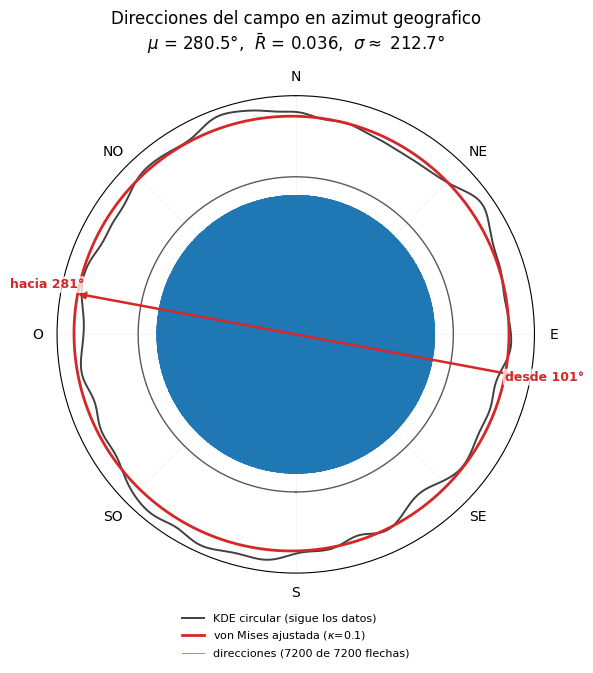


Diagnóstico bimodal:
  modos en 41.5 y -96.0 deg  |  sep 137.5 deg, alto 0.99, dip 0.26
  -> unimodal  (umbrales dip>0.30, alto>0.25, sep>15 deg)


In [32]:
mv = (t >= T_INI) & (t <= T_FIN)

d_pca = (res["vmf_mu_deg"] - res["angle_pca_deg"] + 180.0) % 360.0 - 180.0
print(f"mu(vMF) vs eje PCA : mediana {np.median(np.abs(d_pca[mv])):.1f} deg  |  "
      f"p90 {np.percentile(np.abs(d_pca[mv]), 90):.1f} deg")

for u in (9.0, 10.0):
    tk = F3._primer_sostenido(t, res["vmf_kappa"], u, 2.0, sentido="mayor")
    txt = "no se alcanza" if tk is None else f"t = {tk:.2f} s"
    print(f"kappa > {u:.0f} sostenido 2 s : {txt}"
          f"{'   <- T_INI = %.2f s (criterio B)' % T_INI if u == 9.0 else ''}")

k_in, k_out = res["vmf_kappa"][mv], res["vmf_kappa"][t > T_FIN]
print(f"kappa en la ventana: mediana {np.median(k_in):.1f}  "
      f"(sigma ~ {np.degrees(np.median(k_in)**-0.5):.1f} deg)  |  "
      f"rango {k_in.min():.1f} - {k_in.max():.1f}")
if k_out.size:
    print(f"kappa despues      : mediana {np.median(k_out):.1f}  "
          f"|  maximo de la serie {res['vmf_kappa'].max():.1f} "
          f"en t = {t[res['vmf_kappa'].argmax()]:.2f} s")

fig, VMF = F3.graficar_von_mises(res, t, t_ini=T_INI, t_fin=T_FIN, mostrar_kde =True, geo=geo,
                                 ruta_png=CFG.ruta(3, "von_mises.png"))
plt.show()

print("\nDiagnóstico bimodal:")
BIM = F3.diagnostico_bimodal(res, t, t_ini=T_INI, t_fin=T_FIN)

## F3-11 — Figuras

[fig] resultados\volumetrica\3_viento\wind_imagen.png


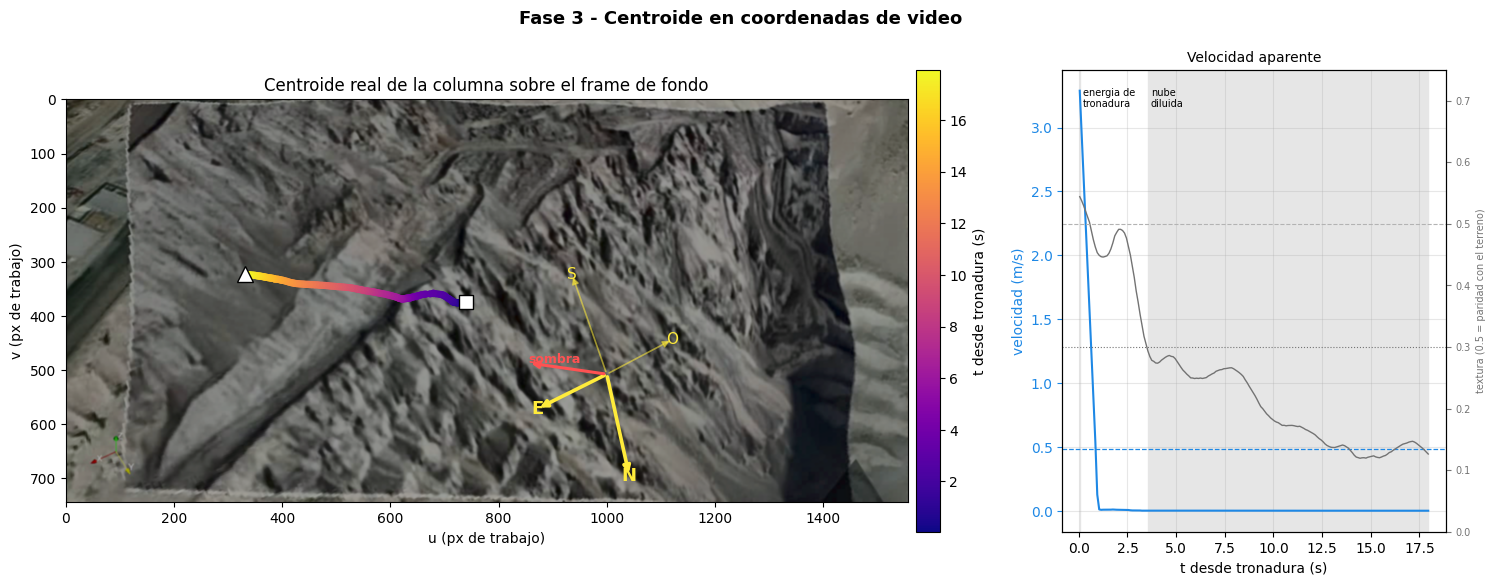

In [33]:
bg = cv2.imread(CFG.ruta(0, "bg_color.png"))

F3.graficar(res, FPS, PF, u_px=u_px, v_px=v_px, bg=bg, cam=cam, dem=dem,
            t_ini=T_INI, t_fin=T_FIN, diag=diag,
            ruta_png=CFG.ruta(3, "wind_imagen.png"))
plt.show()

## F3-12 — Salida

| archivo | columnas |
|---|---|
| `viento_video.csv` | `frame`, `vel_px_frame`, `dir_video_deg` |
| `viento_mundo.csv` | `frame`, `vel_ms`, `dir_desde_deg` |

**Convenciones**, que van en el nombre de la columna para que el archivo se
explique solo:

- `vel_px_frame` — píxeles **nativos** (4K) por frame.
- `dir_video_deg` — 0 = hacia la derecha del cuadro, creciendo en sentido
  **horario en pantalla**. No son puntos cardinales.
- `vel_ms` — m/s horizontales sobre el plano de advección.
- `dir_desde_deg` — azimut meteorológico **DESDE**: de dónde viene el viento,
  0 = Norte, horario. Misma convención que la columna `dd` de la DMC.

In [34]:
SOLO_VENTANA = False    # True = escribe solo las filas de la ventana de viento

calidad = F3.banderas_calidad(CFG, cam, geo, t, T_INI, T_FIN, T_FIN_VEL,
                              info_h, escala=escala, diag=diag,
                              res=res, fps=FPS,
                              deriva=F0._leer_procedencia(CFG)
                                       .get("fases", {}).get("0", {})
                                       .get("procedencia", {}).get("deriva_dron"))
F3.guardar_serie_geo(geo, t, CFG.ruta(3, "viento_georreferenciado.csv"),
                     calidad=calidad)
F0.sellar(CFG, 3, {"calidad": calidad["calidad"], "banderas": calidad["banderas"]})


_ = F3.exportar_series_simples(
    res, t, FPS,
    ruta_video_csv = CFG.ruta(3, "viento_video.csv"),
    geo            = geo,
    ruta_mundo_csv = CFG.ruta(3, "viento_mundo.csv"),
    t_ini=T_INI, t_fin=T_FIN, t_fin_vel=T_FIN_VEL,
    solo_ventana=SOLO_VENTANA)

[csv] 180 filas -> resultados\volumetrica\3_viento\viento_georreferenciado.csv
  calidad: revisar  banderas: desplazamiento_subpixel:0.00px/par
[csv] 181 filas -> resultados\volumetrica\3_viento\viento_video.csv
[csv] 181 filas -> resultados\volumetrica\3_viento\viento_mundo.csv
  ventana de viento establecido: t = [0.1, 3.5] s
    video : 0.113 px/frame   dir 236.4 deg (0 = derecha, horario en pantalla)
    mundo : 0.531 m/s        DESDE 357.6 deg (0 = Norte, horario)
    [ojo] la fila PROMEDIO no es el promedio de las filas de arriba: se calcula solo en la ventana


---

# FASE 4 — Concentracion por adveccion-difusion


La solución de la ecuación de advección-difusión para una emisión instantánea es
lineal en la masa emitida $Q$. El video mide la geometría de la nube, no $Q$, así
que la fase entrega la concentración normalizada

$$\chi = \frac{C}{Q}\qquad[\mathrm{m^{-3}}]$$


## Estructura

| Paso | Entrada | Salida |
|---|---|---|
| 1 | máscaras, geometría, DEM | ventana de trabajo y cámara georreferenciada |
| 2 | máscaras + viento | $\sigma_x(t)$, $\sigma_y(t)$ en metros, sobre el plano de advección |
| 3 | hull 3D de la Fase 2 | $H(t)$, $\sigma_z(t)$, y $\sigma_x,\sigma_y$ con la oblicuidad descontada |
| 4 | los anteriores | $\chi(t)$ en el centro de la nube, $z=H(t)$ |
| 5 | $\chi$ + $Q$ hipotéticas | $C = Q\,\chi$ en µg/m³ |

## F4-0 — ARRANQUE

In [35]:
CTX = F0.iniciar(run=RUN)

CFG, VID              = CTX["CFG"], CTX["VID"]
FPS, N_FRAMES, FIN    = CTX["FPS"], CTX["N_FRAMES"], CTX["FIN"]
H_WORK, W_WORK, FORMA = CTX["H_WORK"], CTX["W_WORK"], CTX["FORMA"]

MOSTRAR = {"leyes", "chi", "huella", "magnitud"} 

def mostrar(fig, clave):
    if clave in MOSTRAR:
        display(fig)
    plt.close(fig)

[config] leida de resultados\volumetrica\config.json

raiz        : .
run         : volumetrica
resultados  : resultados\volumetrica
video       : datos\nube_volumetrica.avi
escala      : 1.0  |  pivote f161  |  GSD None m/px
video   : 1556x744 | 20.00 fps | 521 frames
trabajo : 1556x744 | analisis [161, 521)


## F4-1 — Insumos

Se trabaja sobre el tramo de video en que la máscara admite una medición de
momentos. Un frame entra a la ventana si cumple los cuatro criterios:

| Criterio | Valor | Motivo |
|---|---|---|
| `borde_max` | 0,01 | fracción del borde del cuadro que la máscara puede tocar; por encima, la nube está cortada |
| `cob_max` | 0,35 | cobertura máxima del cuadro; por encima no queda fondo para medir opacidad |
| `area_min` | 500 px | área mínima para que el segundo momento sea estable |
| `salto_max` | 0,60 | variación relativa de área entre frames consecutivos |

La cámara se construye con el DEM, que fija `z_piso`: la cota del terreno bajo el
pivote, origen de todas las alturas de la fase.


In [36]:
CRITERIOS = dict(borde_max=0.01, cob_max=0.35, area_min=500, salto_max=0.60)

masks, _ = F0.cargar_mascaras(CFG.art_mascaras_gas)
met = F4.metricas_por_frame(masks, area_min=CRITERIOS["area_min"])
ventana, ok = F4.ventana_valida(met, CRITERIOS)
if len(ventana) < 10:
    raise RuntimeError(f"¡Alerta!: Ventana de {len(ventana)} frames: insuficiente para "
                       f"ajustar sigma(t).")

with open(CFG.art_geometria, "r", encoding="utf-8") as fh:
    GEOM = json.load(fh)
dem = F3.cargar_dem(CFG.dem) if os.path.exists(CFG.dem) else None
cam = F3.CamaraGeo.desde_config(CFG, dem=dem, verbose=False)

print(f"ventana : f{ventana[0]}-f{ventana[-1]}  "
      f"({len(ventana)} frames, {(ventana[-1]-ventana[0])/FPS:.2f} s)")
print(f"z_piso  : {cam.z_piso:.1f} m")


  DEM EPSG:32719 | archivo (481, 561) | ventana (481, 561) | 12.5 m | z 2216-3373 m
ventana : f161-f520  (181 frames, 17.95 s)
z_piso  : 2759.7 m


## F4-2 — SIGMA MEDIDOS Y LEYES DE CRECIMIENTO


In [37]:
PAR = F4.preparar_dispersion(CFG, masks, cam, FPS, GEOM, ventana=ventana,
                             exigir_calidad=False, verbose=False)

for _n, _l in (("sigma_x", PAR["ley_along"]), ("sigma_y", PAR["ley_cross"])):
    print(f"{_n} : sigma^2 = {_l['sigma0_m']**2:.4g} + {_l['K']:.4g} t^{_l['alpha']:.3f}   "
          f"(sigma_0 = {_l['sigma0_m']:.1f} m, R2 = {_l['r2']:.3f}, "
          f"D_fin = {_l['D_fin_m2s']:.1f} m2/s)")

for _n, _c in (("sigma_x", "sig_along"), ("sigma_y", "sig_cross")):
    _v = F4.ley_sigma(PAR["t"], [f[_c] for f in PAR["filas"]],
                      modelo="potencia", verbose=False)
    print(f"{_n} : alpha = {_v['alpha']:.3f}")
print(f"viento : {PAR['u_ms']:.2f} m/s hacia {PAR['azimut_hacia']:.1f} deg")
print(f"H      : {PAR['H']:.1f} m   [Fase 3, plano de adveccion]")
print(f"ventana medida : {PAR['ley_along']['t_ini']:.2f} - "
      f"{PAR['ley_along']['t_fin']:.2f} s")


sigma_x : sigma^2 = 41.14 + 108.8 t^0.570   (sigma_0 = 6.4 m, R2 = 0.974, D_fin = 9.0 m2/s)
sigma_y : sigma^2 = 137.2 + 52.67 t^0.995   (sigma_0 = 11.7 m, R2 = 0.934, D_fin = 25.8 m2/s)
sigma_x : alpha = 0.452
sigma_y : alpha = 0.510
viento : 0.53 m/s hacia 177.6 deg
H      : 23.5 m   [Fase 3, plano de adveccion]
ventana medida : 0.05 - 17.95 s


## F4-3 — $H$ y $\sigma_z$ desde el hull 3D de la Fase 2


In [38]:
RUTA_GLB = CFG.ruta(2, "gas_secuencia.glb")

if not os.path.exists(RUTA_GLB):
    raise FileNotFoundError(
        f"¡Alerta!: Falta {os.path.basename(RUTA_GLB)}: sin el hull de la Fase 2 no hay "
        f"razon sigma_z/sigma_y.")

PAR_SUPUESTO = PAR
PERFIL3D = F4.perfil_3d_fase2(RUTA_GLB, azimut_hacia=PAR["azimut_hacia"],
                              ruta_serie=CFG.ruta(2, "serie_columna.csv"),
                              verbose=False)

_W   = F4._leer_viento_georref(CFG.ruta(3, "viento_georreferenciado.csv"))
_ok  = np.isfinite(_W["z_adv_m"])
PERFIL3D["cU"] = np.interp(PERFIL3D["frame"], _W["frame"][_ok],
                           _W["z_adv_m"][_ok]) - float(cam.z_piso)

CHK3D    = F4.resumen_fase2(PERFIL3D, PAR,
                            ruta_camara=CFG.ruta(2, "camara_dron.json"),
                            verbose=False)
PAR      = F4.refinar_con_fase2(PAR, cam, PERFIL3D, corregir_plano=False,
                                verbose=False)
EFECTO3D = F4.efecto_refinamiento(PAR_SUPUESTO, PAR, tiempos=[5, 20, 60, 150],
                                  verbose=False)

_d = PAR["fase2"]["despues"]
print(f"altura            : {PERFIL3D['cU'].min():.1f} - {PERFIL3D['cU'].max():.1f} m")
print(f"sigma_z / sigma_y : {CHK3D['razon_vertical_hull']:.3f} "
      f"+- {CHK3D['incertidumbre_razon_pct']:.0f} %")
print(f"\nen t = {PAR['ley_along']['t_fin']:.2f} s")
print(f"  H       : {_d['H_m']:6.2f} m")
for _e, _s, _a in (("sigma_x", "sigma_along_fin", "alpha_along"),
                   ("sigma_y", "sigma_cross_fin", "alpha_cross"),
                   ("sigma_z", "sigma_z_fin",     "alpha_z")):
    print(f"  {_e} : {_d[_s]:6.2f} m   (alpha = {_d[_a]:.2f})")

with open(CFG.ruta(4, "refinamiento_fase2.json"), "w", encoding="utf-8") as fh:
    json.dump(dict(comprobaciones=CHK3D, refinamiento=PAR["fase2"],
                   efecto=EFECTO3D), fh, indent=2, ensure_ascii=False,
              default=F4.json_seguro)

altura            : 4.8 - 30.4 m
sigma_z / sigma_y : 0.673 +- 17 %

en t = 17.95 s
  H       :  29.26 m
  sigma_x :  22.64 m   (alpha = 0.59)
  sigma_y :  32.20 m   (alpha = 1.02)
  sigma_z :  19.22 m   (alpha = 0.49)


## Estimación de dispersiones espaciales ($\sigma_x$, $\sigma_y$, $\sigma_z$)

[fig] resultados\volumetrica\4_pmx\leyes_sigma.png


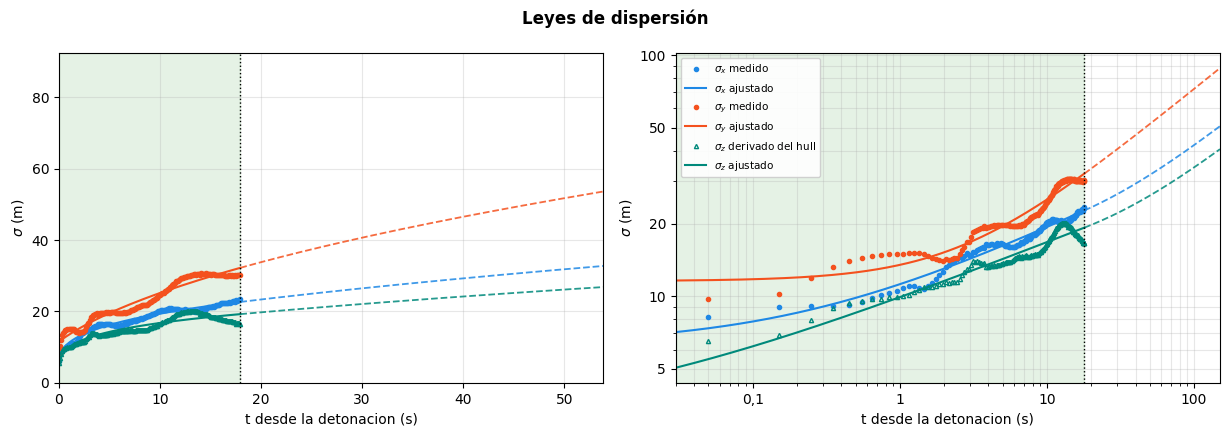

sigma_x: sigma^2 =   39.41 +   86.14 t^0.590   (R2 = 0.966, sigma(17.9 s) =  22.6 m, D_fin =    7.8 m2/s, fickiano)
sigma_y: sigma^2 =   133.3 +   48.21 t^1.015   (R2 = 0.937, sigma(17.9 s) =  32.2 m, D_fin =   25.6 m2/s, fickiano)
sigma_z: sigma^2 =    9.25 +   88.81 t^0.485   (R2 = 0.800, sigma(17.9 s) =  19.2 m, D_fin =    4.9 m2/s, fickiano)
razon sigma_z/sigma_y del hull: mediana 0.673, cae 0.671 -> 0.550 en la ventana


In [39]:
MOSTRAR.add("leyes")

_LEYES = [("x", "sig_along", PAR["ley_along"], "#1E88E5", "o"),
          ("y", "sig_cross", PAR["ley_cross"], "#F4511E", "o")]

if PAR["proyeccion"]["corregido"]:
    _res   = (PERFIL3D["resuelto"] if PERFIL3D["resuelto"].sum() >= 3
              else np.ones(PERFIL3D["n"], bool))
    _razon = np.interp(PAR["t"], PERFIL3D["t"][_res],
                       (PERFIL3D["s_z"] / np.maximum(PERFIL3D["s_cross"], 1e-6))[_res])
    _sz_obs = _razon * np.array([f["sig_cross"] for f in PAR["filas"]], float)
    _LEYES.append(("z", None, PAR["ley_z"], "#00897B", "^"))

_tf  = PAR["ley_along"]["t_fin"]
_t0  = max(PAR["t"].min(), 0.03)
_med = np.geomspace(_t0, _tf, 200)
_ext = np.geomspace(_tf, 150.0, 200)

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.4))
for _eje, _k, _ley, _col, _mk in _LEYES:
    _obs = _sz_obs if _k is None else [f[_k] for f in PAR["filas"]]
    for a in ax:
        a.plot(PAR["t"], _obs, _mk, ms=3.0, color=_col,
               mfc="none" if _k is None else _col,
               label=(f"$\\sigma_{_eje}$ derivado del hull" if _k is None
                      else f"$\\sigma_{_eje}$ medido"))
        a.plot(_med, _ley["sigma"](_med), "-", lw=1.5, color=_col,
               label=f"$\\sigma_{_eje}$ ajustado")
        a.plot(_ext, _ley["sigma"](_ext), "--", lw=1.3, color=_col, alpha=.85)

for a in ax:
    a.axvspan(_t0, _tf, color="green", alpha=.10)
    a.axvline(_tf, color="k", ls=":", lw=1)
    a.set_xlabel("t desde la detonacion (s)")
    a.set_ylabel(r"$\sigma$ (m)")
    a.grid(alpha=.3, which="both")

ax[0].set_xlim(0, 3.0 * _tf); ax[0].set_ylim(0, None)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlim(_t0, 150.0); ax[1].set_xticks([0.1, 1.0, 10.0, 100.0])
ax[1].set_xticklabels(["0,1", "1", "10", "100"])
ax[1].set_yticks([5, 10, 20, 50, 100])
ax[1].set_yticklabels(["5", "10", "20", "50", "100"])
ax[1].legend(fontsize=7.5, loc="upper left", ncol=1, framealpha=.9)

fig.suptitle("Leyes de dispersión", fontweight="bold")
plt.tight_layout()
_png = CFG.ruta(4, "leyes_sigma.png")
fig.savefig(_png, dpi=140, bbox_inches="tight")
print(f"[fig] {F0.ruta_corta(_png)}")
mostrar(fig, "leyes")

for _eje, _k, _ley, _, _ in _LEYES:
    print(f"sigma_{_eje}: sigma^2 = {_ley['sigma0_m']**2:7.4g} + "
          f"{_ley['K']:7.4g} t^{_ley['alpha']:.3f}   "
          f"(R2 = {_ley['r2']:.3f}, sigma({_tf:.1f} s) = {_ley['sigma_fin']:5.1f} m, "
          f"D_fin = {_ley['D_fin_m2s']:6.1f} m2/s, {_ley['regimen']})")
if PAR["proyeccion"]["corregido"]:
    print(f"razon sigma_z/sigma_y del hull: mediana {np.median(_razon):.3f}, "
          f"cae {_razon[0]:.3f} -> {_razon[-1]:.3f} en la ventana")

## F4-4 — Evaluación de $\chi$

Con $u$, $H$ y las tres leyes $\sigma_i(t)$ la expresión del paso 2 queda
determinada. Se evalúa en tres cortes:

- $\chi(t)$ en el centro del puff, $x=ut$, $y=0$, para $z=H$.

$\sigma_i(t)$ está medido hasta $t_{fin}$; más allá la ley se continúa con
$d\sigma_i^2/dt$ constante, es decir con $\alpha_i=1$. En las figuras se distingue
el tramo medido del extrapolado.

[fig] resultados\volumetrica\4_pmx\chi.png


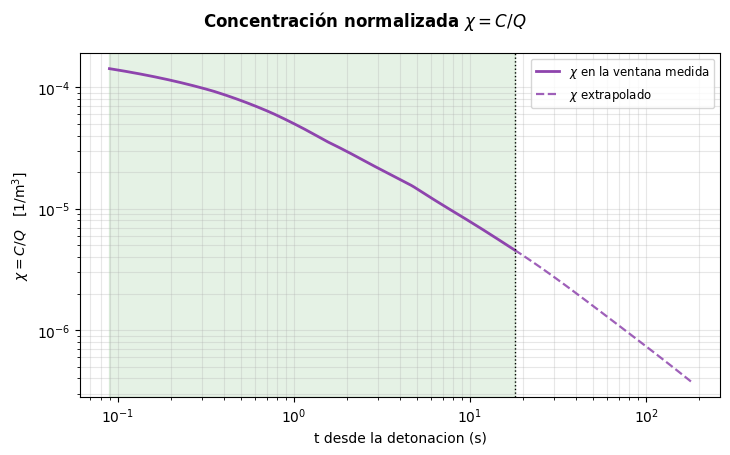

chi(z=H) : 0.000143 -> 4.56e-06 1/m3 en la ventana medida (0.09 - 17.95 s)
chi(150 s) = 3.77e-07 1/m3   [extrapolado]


In [40]:
MOSTRAR.add("chi")

_SER = F4.serie_chi(PAR)
_t   = _SER["t"]
_chi = _SER["chi_nube"]
_tf  = _SER["t_fin_medido"]
_i   = int(np.searchsorted(_t, _tf, side="right"))

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(_t[:_i], _chi[:_i], "-", lw=2.0, color="#8E44AD",
        label=r"$\chi$ en la ventana medida")
ax.plot(_t[max(_i - 1, 0):], _chi[max(_i - 1, 0):], "--", lw=1.6,
        color="#8E44AD", alpha=.85, label=r"$\chi$ extrapolado")
ax.axvspan(_t[0], _tf, color="green", alpha=.10)
ax.axvline(_tf, color="k", ls=":", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("t desde la detonacion (s)")
ax.set_ylabel(r"$\chi = C/Q$   [1/m$^3$]")
ax.grid(alpha=.3, which="both")
ax.legend(fontsize=8.5)

fig.suptitle(r"Concentración normalizada $\chi = C/Q$", fontweight="bold")
plt.tight_layout()
_png = CFG.ruta(4, "chi.png")
fig.savefig(_png, dpi=140, bbox_inches="tight")
print(f"[fig] {F0.ruta_corta(_png)}")
mostrar(fig, "chi")

print(f"chi(z=H) : {np.interp(_t[0], _t, _chi):.3g} -> "
      f"{np.interp(_tf, _t, _chi):.3g} 1/m3 en la ventana medida "
      f"({_t[0]:.2f} - {_tf:.2f} s)")
print(f"chi(150 s) = {_chi[-1]:.3g} 1/m3   [extrapolado]")

In [41]:
Q_HIPOTESIS = [1, 10, 100, 1000]

_SER_R = F4.serie_chi(PAR)
_tf_R  = float(PAR["ley_along"]["t_fin"])

def _resumen_ley(l):
    return {k: l[k] for k in ("alpha", "K", "sigma0_m", "r2", "regimen", "modelo",
                              "modo", "t_min", "t_ini", "t_fin", "sigma_fin",
                              "D_fin_m2s", "n", "origen") if k in l}

_CONC = []
for _tt in (5.0, 20.0, 60.0, 150.0):
    _ch = float(np.interp(_tt, _SER_R["t"], _SER_R["chi_nube"]))
    _CONC.append(dict(t_s=_tt, distancia_m=float(PAR["u_ms"]) * _tt,
                      extrapolado=bool(_tt > _tf_R), chi_1_m3=_ch,
                      C_ug_m3={f"{_q} kg": _q * _ch * 1e9 for _q in Q_HIPOTESIS}))

META = dict(
    unidades="chi = C/Q en 1/m3; C = Q*chi con Q en kg da kg/m3 (x1e9 -> ug/m3)",
    cota_evaluacion="z = H(t), centro de la nube",
    fuente_utm=[float(v) for v in PAR["fuente"]],
    altura_efectiva_m=float(PAR["H"]),
    altura_modelo=("H(t) = centroide del hull (Fase 2), interpolado por instante"
                   if callable(PAR.get("ley_H")) else "H CONSTANTE (sin Fase 2)"),
    viento_ms=float(PAR["u_ms"]), azimut_hacia_deg=float(PAR["azimut_hacia"]),
    ventana_frames=[int(PAR["ventana"][0]), int(PAR["ventana"][-1])],
    ventana_s=[float(PAR["ley_along"]["t_ini"]), _tf_R],
    sigma_along=_resumen_ley(PAR["ley_along"]),
    sigma_cross=_resumen_ley(PAR["ley_cross"]),
    sigma_z=_resumen_ley(PAR["ley_z"]),
    razon_vertical_hull=float(CHK3D["razon_vertical_hull"]),
    incertidumbre_razon_pct=float(CHK3D["incertidumbre_razon_pct"]),
    momentos="pesados por opacidad" if PAR["pesado"] else "SILUETA binaria",
    proyeccion=PAR["proyeccion"], calidad_viento_fase3=PAR["calidad"],
    Q_hipotesis_kg=list(Q_HIPOTESIS), concentraciones=_CONC,
    no_modela=["deposicion/sedimentacion", "terreno (plano con reflexion)",
               "cizalle vertical del viento", "flotabilidad inicial",
               "el ascenso de la fuente en el balance (H(t) entra al evaluar, "
               "no en la ecuacion)"])

_ruta_meta = CFG.ruta(4, "parametros_dispersion.json")
with open(_ruta_meta, "w", encoding="utf-8") as fh:
    json.dump(META, fh, indent=2, ensure_ascii=False, default=F4.json_seguro)
print(f"[artefacto] {F0.ruta_corta(_ruta_meta)}")

F0.sellar(CFG, 4, dict(
    H_m=float(PAR["H"]),
    alpha_along=float(PAR["ley_along"]["alpha"]),
    alpha_cross=float(PAR["ley_cross"]["alpha"]),
    alpha_z=float(PAR["ley_z"]["alpha"]),
    sigma_z_fin_m=float(PAR["ley_z"]["sigma_fin"]),
    t_fin_medido_s=_tf_R,
    chi_t_fin_1_m3=float(np.interp(_tf_R, _SER_R["t"], _SER_R["chi_nube"])),
    pesado=bool(PAR["pesado"]),
    corregido_fase2=bool(PAR["proyeccion"]["corregido"])))
print("[sello] fase 4 anotada en procedencia.json")

[artefacto] resultados\volumetrica\4_pmx\parametros_dispersion.json
[sello] fase 4 anotada en procedencia.json


In [42]:
import pandas as pd

_t = np.asarray(PAR["t"], float)
pd.DataFrame(dict(
    t_s              = _t,
    sig_along        = [f["sig_along"] for f in PAR["filas"]],
    sig_cross        = [f["sig_cross"] for f in PAR["filas"]],
    sig_along_ajuste = PAR["ley_along"]["sigma"](_t),
    sig_cross_ajuste = PAR["ley_cross"]["sigma"](_t),
    sig_z_ajuste     = PAR["ley_z"]["sigma"](_t),
)).to_csv(CFG.ruta(4, "sigmas_medidos.csv"), index=False)

---

# VALIDACIÓN — Contraste contra la simulación

Lee las dos corridas desde `resultados/<run>/` y escribe en
`resultados/validacion/`.

Las referencias se completan en la celda siguiente. Mientras estén
en `None`, B2–B4 grafican las estimaciones sin calcular error.

| Variable | Formato |
|---|---|
| `REF_ALTURA_CSV` | CSV con columnas `frame` (frame del video) y `h_m` |
| `REF_VIENTO` | `vel_ms` y `desde_deg` (azimut meteorológico: de dónde viene) |
| `REF_DIFUSION` | coeficiente de difusión horizontal en m²/s, a favor (`along`) y transversal (`cross`) al viento |

In [43]:
import pandas as pd
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

REF_ALTURA_CSV = None
REF_VIENTO     = dict(vel_ms=None, desde_deg=None)
REF_DIFUSION   = dict(along=None, cross=None)

DIR_VAL = os.path.join("resultados", "validacion")
os.makedirs(DIR_VAL, exist_ok=True)

CFGS  = {r: F0.Config.desde_json(os.path.join("resultados", r, "config.json")) for r in VIDEOS}
MASKS = {r: F0.cargar_mascaras(CFGS[r].art_mascaras_gas)[0] for r in VIDEOS}
FPS_R = {r: F0.propiedades_video(CFGS[r].video)["fps"] for r in VIDEOS}
COLOR = dict(zip(VIDEOS, ["#0072B2", "#D55E00"]))

for r in VIDEOS:
    print(f"{r:12s} pivote f{CFGS[r].pivot_frame}  |  {len(MASKS[r])} máscaras  |  "
          f"escala {CFGS[r].escala}")

volumetrica  pivote f161  |  181 máscaras  |  escala 1.0
difusa       pivote f161  |  181 máscaras  |  escala 1.0


## B1 — Máscara de gas contra la verdad-terreno (Fase 1)

La verdad-terreno es el formato 3 umbralado por color, $R - \max(G, B) > 100$,
descontando los píxeles rojos presentes antes de la tronadura (el eje de
coordenadas del visor).

La cámara del render rojo no coincide con la de los formatos 5 y 6: está
desplazada entre 20 y 50 px y con ~2 % de zoom. La máscara se lleva a la
cámara de la simulación con una homografía estimada por SIFT sobre un frame sin
nube (`FRAME_REG`), interpolando por vecino más cercano.

Métricas por frame: IoU, Dice, razón de áreas (estimada / verdadera) y falsos
positivos y negativos relativos al área verdadera.

In [44]:
UMBRAL_ROJO = 100
FRAME_REG   = 100

def leer_frame(ruta, i):
    cap = cv2.VideoCapture(ruta)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
    ok, fr = cap.read()
    cap.release()
    return fr if ok else None

def rojo(fr):
    fr = fr.astype(np.int16)
    return (fr[..., 2] - np.maximum(fr[..., 1], fr[..., 0])) > UMBRAL_ROJO

_cfg0   = CFGS[next(iter(VIDEOS))]
RUTA_GT = os.path.join(_cfg0.dir_datos, VIDEO_GT)
_ref = cv2.cvtColor(leer_frame(_cfg0.video, FRAME_REG), cv2.COLOR_BGR2GRAY)
_gt0 = leer_frame(RUTA_GT, FRAME_REG)

_sift = cv2.SIFT_create(4000)
_k1, _d1 = _sift.detectAndCompute(cv2.cvtColor(_gt0, cv2.COLOR_BGR2GRAY), None)
_k2, _d2 = _sift.detectAndCompute(_ref, None)
_par = [a for a, b in cv2.BFMatcher().knnMatch(_d1, _d2, k=2)
        if a.distance < 0.75 * b.distance]
_p1 = np.float32([_k1[a.queryIdx].pt for a in _par])
_p2 = np.float32([_k2[a.trainIdx].pt for a in _par])
H_GT, _inl = cv2.findHomography(_p1, _p2, cv2.RANSAC, 2.0)
_inl = _inl.ravel() > 0
_res = np.linalg.norm(cv2.perspectiveTransform(_p1[_inl][None], H_GT)[0] - _p2[_inl], axis=1)
print(f"registro GT -> simulacion: {_inl.sum()}/{len(_par)} pares, "
      f"residuo mediano {np.median(_res):.2f} px")

ESTATICO = cv2.dilate(rojo(_gt0).astype(np.uint8), np.ones((5, 5), np.uint8)) > 0
H_NAT, W_NAT = _ref.shape
_frames = set().union(*[set(m) for m in MASKS.values()])

GT = {}
cap = cv2.VideoCapture(RUTA_GT)
f = 0
while True:
    ok, fr = cap.read()
    if not ok:
        break
    if f in _frames:
        g = (rojo(fr) & ~ESTATICO).astype(np.uint8) * 255
        GT[f] = cv2.warpPerspective(g, H_GT, (W_NAT, H_NAT), flags=cv2.INTER_NEAREST)
    f += 1
cap.release()
print(f"GT: {len(GT)} frames")

filas = []
for r in VIDEOS:
    pf  = CFGS[r].pivot_frame
    fps = FPS_R[r]
    for f, m in sorted(MASKS[r].items()):
        if f not in GT:
            continue
        p = F0.normalizar_mascara(m) > 0
        g = F0.normalizar_mascara(GT[f], p.shape) > 0
        ag, ap = int(g.sum()), int(p.sum())
        if ag == 0:
            continue
        tp = int((p & g).sum())
        fp, fn = ap - tp, ag - tp
        filas.append(dict(run=r, frame=int(f), t_s=(f - pf) / fps,
                          area_gt=ag, area_pred=ap,
                          iou=tp / (tp + fp + fn), dice=2 * tp / (ap + ag),
                          razon_area=ap / ag, fp_rel=fp / ag, fn_rel=fn / ag))
V1 = pd.DataFrame(filas)

registro GT -> simulacion: 801/1125 pares, residuo mediano 0.84 px
GT: 181 frames


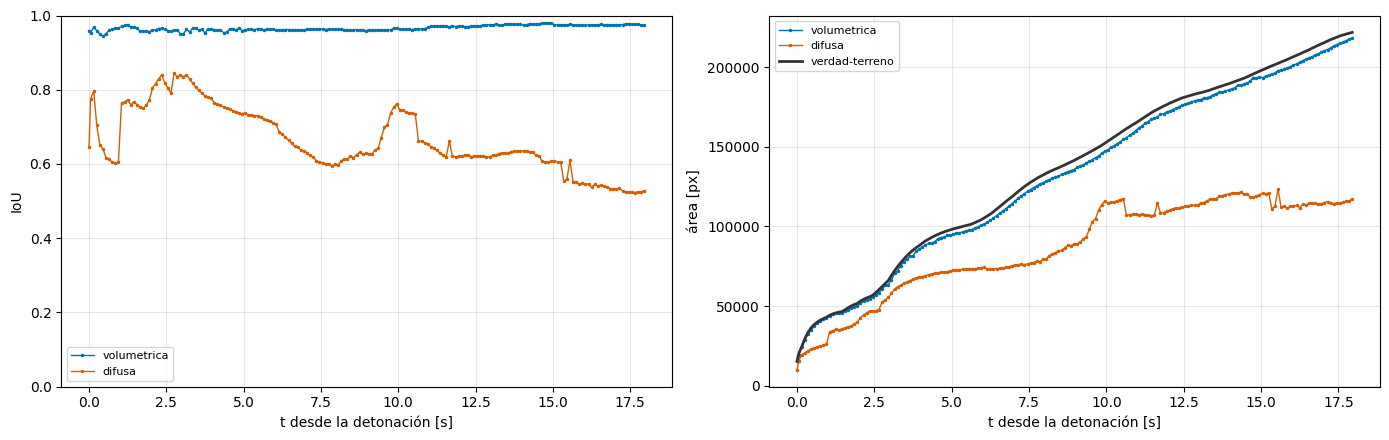

,iou,dice,razon_area,fp_rel,fn_rel
run,,,,,
difusa,0.635,0.777,0.635,0.000,0.365
volumetrica,0.964,0.982,0.974,0.001,0.031


In [45]:
V1.to_csv(os.path.join(DIR_VAL, "v1_mascaras_vs_gt.csv"), index=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for r in VIDEOS:
    d = V1[V1.run == r]
    ax[0].plot(d.t_s, d.iou, ".-", ms=3, lw=1, color=COLOR[r], label=r)
    ax[1].plot(d.t_s, d.area_pred, ".-", ms=3, lw=1, color=COLOR[r], label=r)
d = V1.drop_duplicates("frame").sort_values("frame")
ax[1].plot(d.t_s, d.area_gt, "-", lw=2, color="0.2", label="verdad-terreno")
ax[0].set_ylabel("IoU"); ax[0].set_ylim(0, 1)
ax[1].set_ylabel("área [px]")
for a in ax:
    a.set_xlabel("t desde la detonación [s]"); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DIR_VAL, "v1_iou_area.png"), dpi=120); plt.show()

display(V1.groupby("run")[["iou", "dice", "razon_area", "fp_rel", "fn_rel"]]
          .median().round(3))

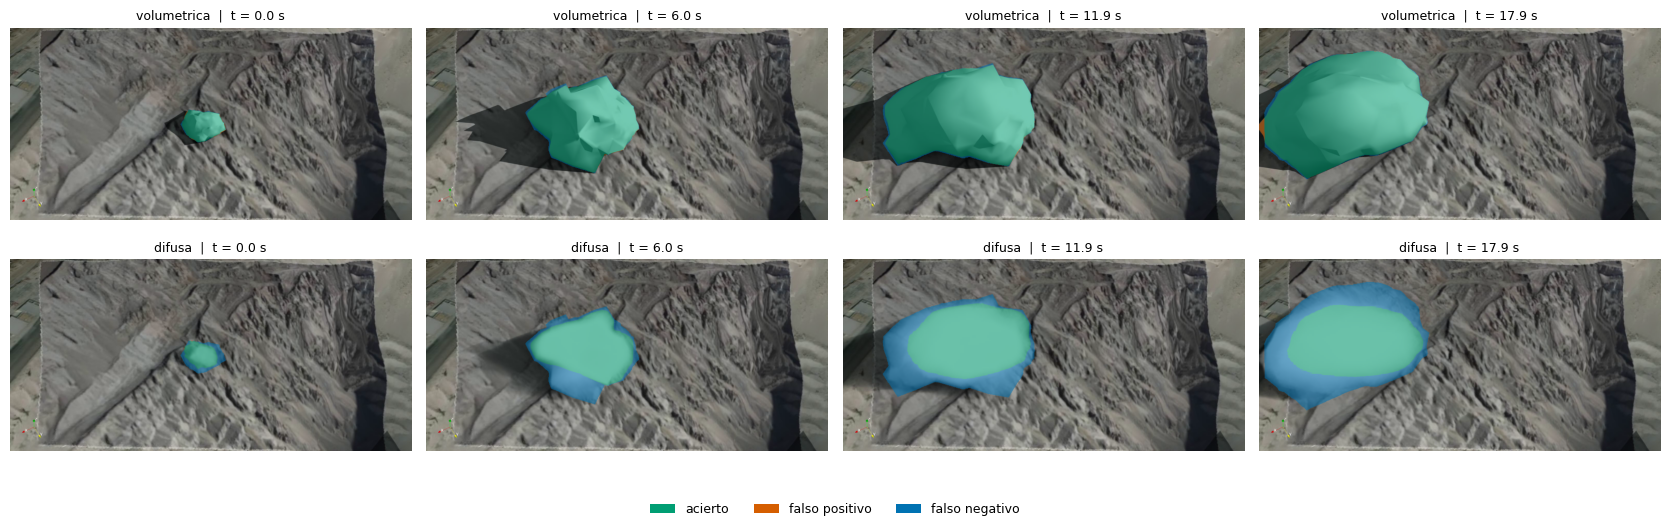

In [46]:
N_OVL = 4

_com = sorted(set.intersection(*[set(V1[V1.run == r].frame) for r in VIDEOS]))
FR_OVL = [_com[i] for i in np.unique(np.linspace(0, len(_com) - 1, N_OVL).round().astype(int))]
CAPAS_V1 = [("acierto", "#009E73"), ("falso positivo", "#D55E00"),
            ("falso negativo", "#0072B2")]

fig, axs = plt.subplots(len(VIDEOS), len(FR_OVL),
                        figsize=(4.2 * len(FR_OVL), 2.7 * len(VIDEOS)))
axs = np.atleast_2d(axs)
for i, r in enumerate(VIDEOS):
    for j, f in enumerate(FR_OVL):
        p = F0.normalizar_mascara(MASKS[r][f]) > 0
        g = F0.normalizar_mascara(GT[f], p.shape) > 0
        base = cv2.resize(leer_frame(CFGS[r].video, f), (p.shape[1], p.shape[0]))
        base = base[:, :, ::-1].astype(np.float32)
        for m, (_, c) in zip((p & g, p & ~g, ~p & g), CAPAS_V1):
            base[m] = 0.45 * base[m] + 0.55 * np.array(to_rgb(c)) * 255
        axs[i, j].imshow(base.astype(np.uint8)); axs[i, j].axis("off")
        axs[i, j].set_title(f"{r}  |  t = {(f - CFGS[r].pivot_frame) / FPS_R[r]:.1f} s",
                            fontsize=9)
fig.legend(handles=[Patch(facecolor=c, label=n) for n, c in CAPAS_V1],
           loc="lower center", ncol=3, frameon=False, fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(DIR_VAL, "v1_comparacion.png"), dpi=120); plt.show()

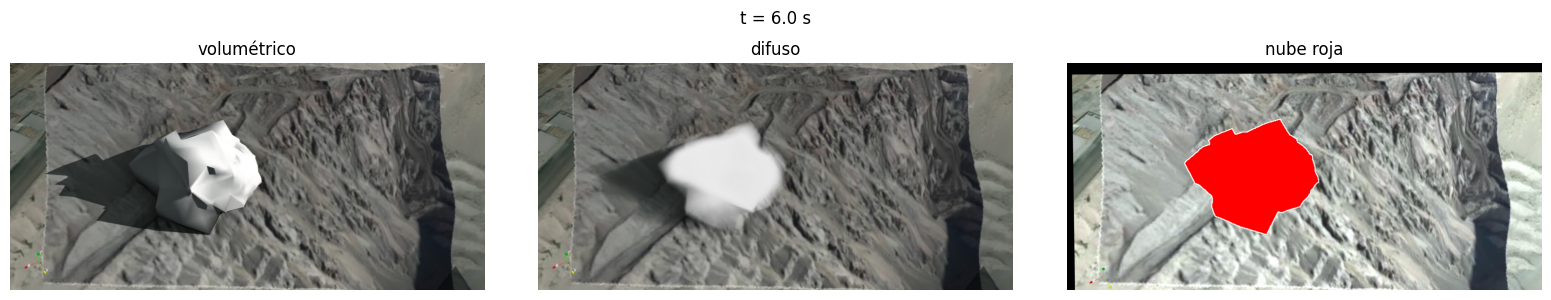

In [47]:
F_FIG = min(GT, key=lambda f: abs(f - 281))

_fr  = {r: leer_frame(CFGS[r].video, F_FIG) for r in VIDEOS}
_roj = cv2.warpPerspective(leer_frame(RUTA_GT, F_FIG), H_GT, (W_NAT, H_NAT))
_c, _ = cv2.findContours((GT[F_FIG] > 0).astype(np.uint8), cv2.RETR_EXTERNAL,
                         cv2.CHAIN_APPROX_NONE)
cv2.drawContours(_roj, _c, -1, (255, 255, 255), 2)

_t = (F_FIG - CFGS["volumetrica"].pivot_frame) / FPS_R["volumetrica"]
_paneles = [(_fr["volumetrica"], "volumétrico"), (_fr["difusa"], "difuso"),
            (_roj, "nube roja")]

fig, ax = plt.subplots(1, 3, figsize=(16, 2.9))
for a, (img, tit) in zip(ax, _paneles):
    a.imshow(img[:, :, ::-1]); a.set_title(tit); a.axis("off")
fig.suptitle(f"t = {_t:.1f} s", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DIR_VAL, "v1_formatos.png"), dpi=200, bbox_inches="tight"); plt.show()

## B2 — Altura de la columna (Fase 2)

`h_m` de `serie_columna.csv` contra la altura de la simulación, en los frames que
cubre la referencia. Error = estimado − simulación: sesgo medio, error absoluto
medio, error relativo medio y pendiente del error en el tiempo.

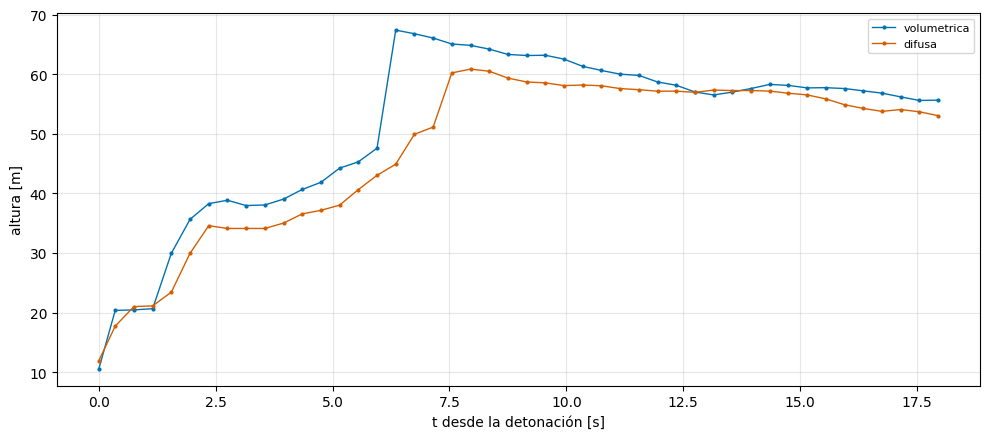

In [48]:
REF_H = pd.read_csv(REF_ALTURA_CSV) if REF_ALTURA_CSV else None

filas = []
fig, ax = plt.subplots(figsize=(10, 4.5))
for r in VIDEOS:
    s = pd.read_csv(CFGS[r].art_serie_columna)
    ax.plot(s.t_s, s.h_m, ".-", ms=4, lw=1, color=COLOR[r], label=r)
    if REF_H is None:
        continue
    s = s[(s.frame >= REF_H.frame.min()) & (s.frame <= REF_H.frame.max())]
    h_ref = np.interp(s.frame, REF_H.frame, REF_H.h_m)
    e = s.h_m.to_numpy() - h_ref
    filas.append(dict(run=r, n=len(s), sesgo_m=e.mean(), mae_m=np.abs(e).mean(),
                      error_rel=np.mean(np.abs(e) / h_ref),
                      pendiente_error_m_s=np.polyfit(s.t_s, e, 1)[0]))
if REF_H is not None:
    _r0 = next(iter(VIDEOS))
    ax.plot((REF_H.frame - CFGS[_r0].pivot_frame) / FPS_R[_r0], REF_H.h_m, "-",
            lw=2, color="0.2", label="simulación")
ax.set_xlabel("t desde la detonación [s]"); ax.set_ylabel("altura [m]")
ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DIR_VAL, "v2_altura.png"), dpi=120); plt.show()

V2 = pd.DataFrame(filas)
if len(V2):
    V2.to_csv(os.path.join(DIR_VAL, "v2_altura.csv"), index=False)
    display(V2.round(3))

## B3 — Viento (Fase 3)

Serie de `viento_georreferenciado.csv` y, en línea discontinua, el valor de la
ventana de viento establecido que consume la Fase 4 (`parametros_dispersion.json`).
El error de dirección se calcula en $[-180°, 180°)$.

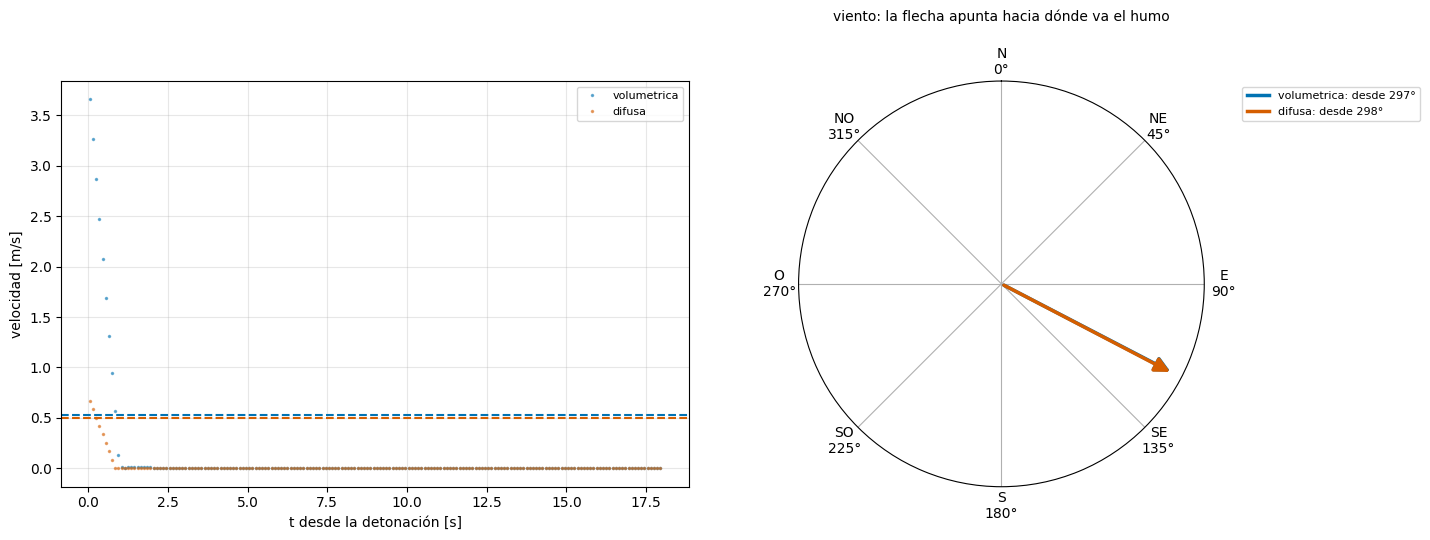

,run,desde_deg,vel_ms
0,volumetrica,297.430,0.531
1,difusa,297.557,0.501


In [49]:
def azimut_pca(E, N):
    X = np.column_stack([E, N]).astype(float)
    X = X[np.isfinite(X).all(1)]
    Xc = X - X.mean(0)
    d = np.linalg.eigh(Xc.T @ Xc)[1][:, -1]
    if d @ (X[-1] - X[0]) < 0:
        d = -d
    return float(np.degrees(np.arctan2(d[0], d[1])) % 360.0)

def flecha(ax, hacia_deg, color, etiqueta, lw=2.5):
    ax.annotate("", xy=(np.radians(hacia_deg), 1.0), xytext=(0.0, 0.0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=22))
    ax.plot([], [], color=color, lw=lw, label=etiqueta)

filas = []
fig = plt.figure(figsize=(15, 5.5))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2, projection="polar")
ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
for r in VIDEOS:
    S = pd.read_csv(CFGS[r].ruta(3, "viento_georreferenciado.csv"))
    ax0.plot(S.t_s, S.vel_ms, ".", ms=3, alpha=.5, color=COLOR[r], label=r)
    hacia = azimut_pca(S.utm_e, S.utm_n)
    desde = (hacia + 180.0) % 360.0
    flecha(ax1, hacia, COLOR[r], f"{r}: desde {desde:.0f}°")
    fila = dict(run=r, desde_deg=desde, vel_ms=np.nan)
    _rp = CFGS[r].ruta(4, "parametros_dispersion.json")
    if os.path.exists(_rp):
        with open(_rp, encoding="utf-8") as fh:
            P = json.load(fh)
        fila["vel_ms"] = P["viento_ms"]
        ax0.axhline(P["viento_ms"], ls="--", lw=1.5, color=COLOR[r])
    else:
        print(f"{r}: sin parametros_dispersion.json (Fase 4 no terminó)")
    if REF_VIENTO["vel_ms"] is not None:
        fila.update(err_vel_ms=fila["vel_ms"] - REF_VIENTO["vel_ms"],
                    err_vel_rel=fila["vel_ms"] / REF_VIENTO["vel_ms"] - 1.0)
    if REF_VIENTO["desde_deg"] is not None:
        fila.update(err_dir_deg=(desde - REF_VIENTO["desde_deg"] + 180.0) % 360.0 - 180.0)
    filas.append(fila)

if REF_VIENTO["vel_ms"] is not None:
    ax0.axhline(REF_VIENTO["vel_ms"], lw=2, color="0.2", label="simulación")
ax0.set_xlabel("t desde la detonación [s]"); ax0.set_ylabel("velocidad [m/s]")
ax0.grid(alpha=.3); ax0.legend(fontsize=8)

if REF_VIENTO["desde_deg"] is not None:
    flecha(ax1, (REF_VIENTO["desde_deg"] + 180.0) % 360.0, "0.2",
           f"simulación: desde {REF_VIENTO['desde_deg']:.0f}°")
_card = ["N", "NE", "E", "SE", "S", "SO", "O", "NO"]
ax1.set_thetagrids(np.arange(0, 360, 45),
                   [f"{c}\n{g}°" for c, g in zip(_card, range(0, 360, 45))])
ax1.set_ylim(0.0, 1.05)
ax1.set_yticks([])
ax1.set_title("viento: la flecha apunta hacia dónde va el humo", fontsize=10, pad=18)
ax1.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.08, 1.0))
plt.tight_layout()
plt.savefig(os.path.join(DIR_VAL, "v3_viento.png"), dpi=120); plt.show()

V3 = pd.DataFrame(filas)
V3.to_csv(os.path.join(DIR_VAL, "v3_viento.csv"), index=False)
display(V3.round(3))

## B4 — Difusión (Fase 4)

De las leyes $\sigma^2(t) = \sigma_0^2 + K\,t^{\alpha}$ ajustadas en F4-2 sale el
coeficiente equivalente

$$D(t) = \frac{1}{2}\frac{d\sigma^2}{dt} = \frac{1}{2}\,K\,\alpha\,t^{\alpha-1},$$

graficado sobre la ventana medida y comparado con el $D$ de la simulación por su
valor al final de la ventana (`D_fin_m2s`). La comparación supone difusión
fickiana con $D$ constante en la simulación.

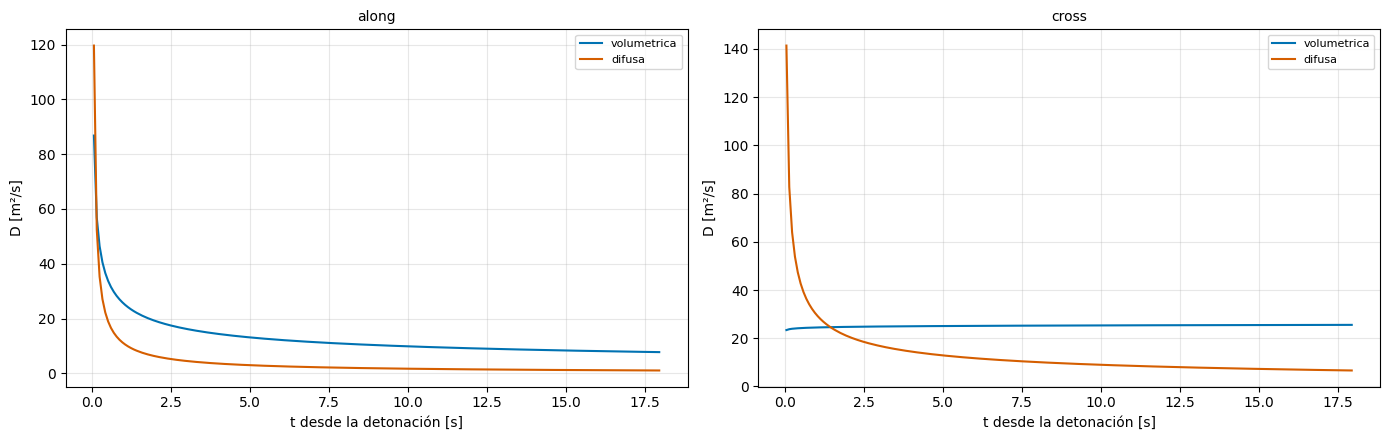

,run,eje,alpha,r2,D_fin_m2s
0,volumetrica,along,0.590,0.966,7.778
1,volumetrica,cross,1.015,0.937,25.550
2,difusa,along,0.200,0.357,1.081
3,difusa,cross,0.480,0.943,6.634


In [50]:
filas = []
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for r in VIDEOS:
    _rp = CFGS[r].ruta(4, "parametros_dispersion.json")
    if not os.path.exists(_rp):
        print(f"{r}: sin parametros_dispersion.json (Fase 4 no terminó)")
        continue
    with open(_rp, encoding="utf-8") as fh:
        P = json.load(fh)
    for a, eje in ((ax[0], "along"), (ax[1], "cross")):
        L = P[f"sigma_{eje}"]
        tt = np.linspace(L["t_ini"], L["t_fin"], 200)
        a.plot(tt, 0.5 * L["K"] * L["alpha"] * tt ** (L["alpha"] - 1.0),
               lw=1.5, color=COLOR[r], label=r)
        fila = dict(run=r, eje=eje, alpha=L["alpha"], r2=L["r2"],
                    D_fin_m2s=L["D_fin_m2s"])
        if REF_DIFUSION[eje] is not None:
            fila.update(err_D_rel=L["D_fin_m2s"] / REF_DIFUSION[eje] - 1.0)
        filas.append(fila)
for a, eje in ((ax[0], "along"), (ax[1], "cross")):
    if REF_DIFUSION[eje] is not None:
        a.axhline(REF_DIFUSION[eje], lw=2, color="0.2", label="simulación")
    a.set_title(eje, fontsize=10)
    a.set_xlabel("t desde la detonación [s]"); a.set_ylabel("D [m²/s]")
    a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DIR_VAL, "v4_difusion.png"), dpi=120); plt.show()

V4 = pd.DataFrame(filas)
if len(V4):
    V4.to_csv(os.path.join(DIR_VAL, "v4_difusion.csv"), index=False)
    display(V4.round(3))

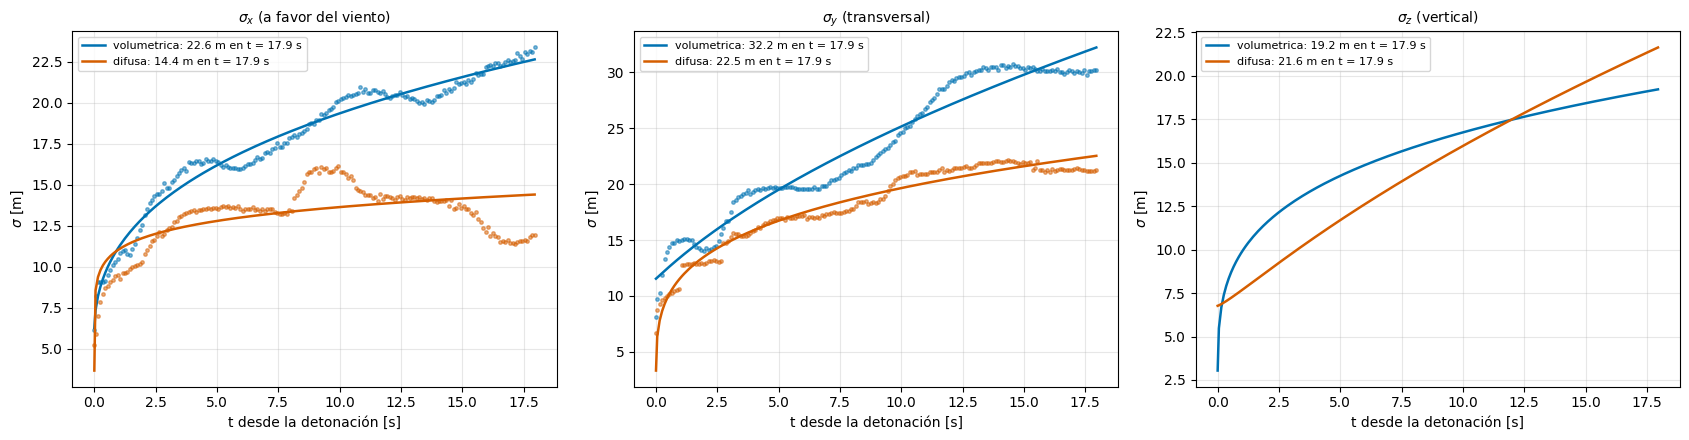

In [51]:
EJES = (("sig_along", r"$\sigma_x$ (a favor del viento)"),
        ("sig_cross", r"$\sigma_y$ (transversal)"),
        ("sig_z",     r"$\sigma_z$ (vertical)"))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for r in VIDEOS:
    _rs = CFGS[r].ruta(4, "sigmas_medidos.csv")
    if not os.path.exists(_rs):
        print(f"{r}: sin sigmas_medidos.csv (correr la celda nueva de la Fase 4)")
        continue
    S = pd.read_csv(_rs)
    for a, (k, _) in zip(ax, EJES):
        if k in S:
            a.plot(S.t_s, S[k], "o", ms=2.5, alpha=.5, color=COLOR[r])
        a.plot(S.t_s, S[f"{k}_ajuste"], "-", lw=1.8, color=COLOR[r],
               label=f"{r}: {S[f'{k}_ajuste'].iloc[-1]:.1f} m en t = {S.t_s.iloc[-1]:.1f} s")
for a, (_, nom) in zip(ax, EJES):
    a.set_title(nom, fontsize=10)
    a.set_xlabel("t desde la detonación [s]"); a.set_ylabel(r"$\sigma$ [m]")
    a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DIR_VAL, "v4_sigmas.png"), dpi=120); plt.show()

## B5 — Resumen

In [52]:
RESUMEN = pd.DataFrame(index=list(VIDEOS))
_g = V1.groupby("run")
RESUMEN["F1 IoU (mediana)"]       = _g.iou.median()
RESUMEN["F1 Dice (mediana)"]      = _g.dice.median()
RESUMEN["F1 área est./GT (med.)"] = _g.razon_area.median()
if len(V2):
    RESUMEN["F2 sesgo altura [m]"] = V2.set_index("run").sesgo_m
    RESUMEN["F2 MAE altura [m]"]   = V2.set_index("run").mae_m
if len(V3):
    _v = V3.set_index("run")
    RESUMEN["F3 viento [m/s]"] = _v.vel_ms
    RESUMEN["F3 DESDE [deg]"]  = _v.desde_deg
    for k, n in (("err_vel_rel", "F3 error vel. rel."), ("err_dir_deg", "F3 error dir. [deg]")):
        if k in _v:
            RESUMEN[n] = _v[k]
if len(V4):
    for eje in ("along", "cross"):
        _d = V4[V4.eje == eje].set_index("run")
        RESUMEN[f"F4 D {eje} [m²/s]"] = _d.D_fin_m2s
        if "err_D_rel" in _d:
            RESUMEN[f"F4 error D {eje} rel."] = _d.err_D_rel

RESUMEN.to_csv(os.path.join(DIR_VAL, "resumen.csv"))
display(RESUMEN.T.round(3))

,volumetrica,difusa
F1 IoU (mediana),0.964,0.635
F1 Dice (mediana),0.982,0.777
F1 área est./GT (med.),0.974,0.635
F3 viento [m/s],0.531,0.501
F3 DESDE [deg],297.430,297.557
F4 D along [m²/s],7.778,1.081
F4 D cross [m²/s],25.550,6.634
